# Sentence Memorability Experiment — Analysis Notebook

---

## Experimental Background

This experiment investigates how the **memorability of Subject–Verb–Object (S–V–O) sentences** is
shaped by the **memorability of their constituent nouns** and **sentence voice** (active vs. passive).

### Stimulus Design

Sentences were constructed by systematically varying the memorability of the **subject** and
**object** nouns using established word-memorability norms. Verbs were drawn from a fixed pool of
medium-concreteness action verbs to minimise confounding variability. This yielded **four
word-memorability conditions**:

| Code | Subject Noun | Object Noun | Example |
|------|-------------|-------------|---------|
| **HH** | High memorability | High memorability | *The eagle carries the lantern* |
| **HL** | High memorability | Low memorability  | *The eagle carries the notion*  |
| **LH** | Low memorability  | High memorability | *The factor carries the lantern* |
| **LL** | Low memorability  | Low memorability  | *The factor carries the notion*  |

Each sentence was also produced in **active** and **passive** voice, yielding **8 experimental
conditions** (HH, HL, LH, LL × Active, Passive) — 50 sentences per condition, **400 sentences
in total**.

### Procedure

Participants completed a **continuous recognition task**. Each participant encountered **48 target
sentences** across **3 blocks** (~16 targets per block). Each target appeared twice — once as a
first presentation and once as a repeat, either in the **same voice (exact repetition)** or a
**voice-transformed** form (active ↔ passive). Two responses were collected:

- **Information Recognition (IR):** Press spacebar when the sentence conveys the *same meaning* as
  a previously seen sentence (regardless of exact wording). Captures **gist-level memory**.
- **Word Recognition (WR):** After pressing spacebar, indicate *A (Yes)* if the sentence was
  word-for-word identical, or *D (No)* if it was a voice-transformed paraphrase. Captures
  **verbatim surface-form memory**.

### Target Sample Size

A total of **334 successfully completing participants** are required based on a power analysis
for the primary hypotheses.

---

## Research Question

> **How is the memorability of sentences affected by their syntactic structure (active vs. passive
voice) and the memorability of their constituent nouns (High / Low)?**

### Hypotheses

**H1 — Word Memorability Effect**
Sentences composed of higher-memorability nouns (**HH > HL, LH > LL**) will produce higher
corrected memorability scores (Pr = Hit Rate − False Alarm Rate), reflecting more robust
encoding when constituent nouns are independently more memorable.

**H2 — Voice Effect**
Active sentences will show higher memorability than their passive counterparts. Active voice is
the canonical English sentence form and places the agent — typically the higher-memorability
entity — in the structurally and perceptually salient subject position.

**H3 — Word Memorability × Voice Interaction**
The memorability advantage of high-memorability nouns may be modulated by voice. The subject-
position advantage should be more pronounced in active sentences, where the subject role is
thematically and structurally prominent.


---
## Analysis Pipeline

The full analysis proceeds in the following steps:

**Step 1 — Data Loading & Preprocessing**
Parse raw log files; extract word condition (HH/HL/LH/LL), voice (active/passive), sentence ID,
and all response events (IR press, WR press, reaction times).

**Step 2 — Block Validation & Exclusion**
Apply the per-block attention criterion and exclude failing blocks and participants.
> *Validation formula:* `Correct IR Hits > (False Alarm IRs ÷ 2) + Missed IR responses`
> Participants with fewer than 2/3 valid blocks are excluded entirely.

**Step 3 — Corrected Memorability Score (Pr)**
Compute Pr = Hit Rate − False Alarm Rate at the participant × condition level.
This removes response bias, following the recognition memory tradition of the cited literature.

**Step 4 — Behavioural Overview**
Visualise the distribution of trial outcomes (Hits, Misses, FAs, Correct Rejections)
across all 8 conditions (Figure 2).

**Step 5 — Memorability Analysis**
Plot corrected memorability for all 8 conditions (Figure 3), and isolate the main effects of
word memorability (Figure 4), voice (Figure 5), and their interaction (Figure 6).

**Step 6 — Statistical Tests (Kruskal–Wallis)**
Non-parametric omnibus tests across all 8 conditions, the 4 word-memorability levels, and the
2 voice levels. Post-hoc pairwise comparisons via Dunn's test (Bonferroni-corrected; Figure 7).

**Step 7 — Reaction Time Analysis**
IR response latencies by condition (Figure 8) as a convergent measure of recognition ease.

**Step 8 — Voice Recognition (WR)**
Accuracy in detecting exact vs. voice-transformed repetitions by word condition (Figure 9),
testing whether surface-form memory co-varies with noun memorability.

**Step 9 — Sentence-Level Variability**
Raindrop plots of individual sentence memorability distributions (Figure 10) to characterise
within-condition spread and identify ceiling/floor effects.

**Step 10 — Summary**
Per-condition performance table and heatmap overview (Figure 11).


---
## Section 0 · Data Loading & Preprocessing
---

In [1]:
import pandas as pd
import numpy as np
import os
import itertools
import warnings
from scipy import stats
from scipy.stats import kruskal, norm as _norm, mannwhitneyu, wilcoxon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")

DATA_FOLDER = "data"

# ── Voice label map: raw codes → readable strings ─────────────────────────────
VOICE_MAP = {"a": "active", "p": "passive", "1": "active", "2": "passive",
             "active": "active", "passive": "passive"}

def parse_stimulus(stim):
    """
    Format: <word_condition>_<sentence_id>_<voice_code>
    e.g.  HF_2_a  →  ('HF', '2', 'a')
    """
    parts = str(stim).strip().split("_")
    if len(parts) < 3:
        return None, None, None
    return parts[0].upper(), parts[1], parts[2].lower()

def process_log(file_path):
    df = pd.read_csv(file_path)
    participant_id = df["participant_ID"].iloc[0]
    seen_meaning, seen_exact = set(), set()
    trials, current_trial = [], None

    for _, row in df.iterrows():
        event = row["Event"]
        stim  = row["Stimulus"]
        if pd.isna(stim) and event != "gap_time":
            continue

        if event == "Sentence shown":
            word_cond, sid, voice_raw = parse_stimulus(stim)
            if word_cond is None:
                continue
            voice = VOICE_MAP.get(voice_raw, voice_raw)   # normalise to 'active'/'passive'
            semantic_repeat = (word_cond, sid) in seen_meaning
            exact_repeat    = stim in seen_exact
            current_trial = {
                "participant":     participant_id,
                "stimulus":        stim,
                "word_condition":  word_cond,
                "sentence_id":     sid,
                "voice":           voice,
                "condition_full":  f"{word_cond}_{voice}",
                "semantic_repeat": semantic_repeat,
                "exact_repeat":    exact_repeat,
                "ir_pressed":      False,
                "wr_response":     None,
                "rt_ir":           None,
                "rt_wr":           None,
            }
            seen_meaning.add((word_cond, sid))
            seen_exact.add(stim)

        elif event == "IR pressed" and current_trial is not None:
            current_trial["ir_pressed"] = True
            current_trial["rt_ir"]      = row.get("Reaction_time_IR", None)

        elif event == "WR pressed" and current_trial is not None:
            current_trial["wr_response"] = row.get("Button", None)
            current_trial["rt_wr"]       = row.get("Reaction_time_WR", None)

        elif event == "gap_time" and current_trial is not None:
            trials.append(current_trial)
            current_trial = None

    return pd.DataFrame(trials)

all_trials = []
for fn in sorted(os.listdir(DATA_FOLDER)):
    if fn.endswith(".log"):
        all_trials.append(process_log(os.path.join(DATA_FOLDER, fn)))

trial_df = pd.concat(all_trials, ignore_index=True)

# Block assignment (3 equal blocks per participant)
trial_df["trial_index"] = trial_df.groupby("participant").cumcount()

def assign_block(grp):
    n = len(grp)
    return ((grp["trial_index"] / (n / 3)).clip(upper=2.999).astype(int) + 1)

trial_df["block"] = trial_df.groupby("participant", group_keys=False).apply(assign_block)

print(f"Loaded {len(trial_df):,} trials from {trial_df['participant'].nunique()} participants")
print(f"Word conditions : {sorted(trial_df['word_condition'].dropna().unique())}")
print(f"Voice types     : {sorted(trial_df['voice'].dropna().unique())}")
trial_df.head(3)


Loaded 25,308 trials from 114 participants
Word conditions : ['HF', 'HH', 'HVL', 'LVH', 'LVL']
Voice types     : ['active', 'passive']


,participant,stimulus,word_condition,sentence_id,voice,condition_full,semantic_repeat,exact_repeat,ir_pressed,wr_response,rt_ir,rt_wr,trial_index,block
0,232,HF_29_A,HF,29,active,HF_active,False,False,False,NaN,NaN,NaN,0,1
1,232,HF_9_A,HF,9,active,HF_active,False,False,False,NaN,NaN,NaN,1,1
2,232,HF_24_A,HF,24,active,HF_active,False,False,False,NaN,NaN,NaN,2,1


In [2]:
# ── Signal-detection outcome labels ──────────────────────────────────────────
def classify_outcome(row):
    if row.semantic_repeat and row.ir_pressed:      return "Hit"
    if row.semantic_repeat and not row.ir_pressed:  return "Miss"
    if not row.semantic_repeat and row.ir_pressed:  return "False Alarm"
    return "Correct Reject"

trial_df["outcome"] = trial_df.apply(classify_outcome, axis=1)

# ── WR sub-dataset ────────────────────────────────────────────────────────────
wr_df = trial_df[trial_df["wr_response"].notna()].copy()

def wr_is_correct(row):
    if row["exact_repeat"]  and row["wr_response"] == "Yes": return 1
    if not row["exact_repeat"] and row["wr_response"] == "No": return 1
    return 0

wr_df["wr_correct"] = wr_df.apply(wr_is_correct, axis=1)

print("Outcome distribution (proportion across all trials):")
print(trial_df["outcome"].value_counts(normalize=True).round(3))
print(f"\nWR trials available: {len(wr_df):,}")


Outcome distribution (proportion across all trials):
outcome
Correct Reject    0.566
Hit               0.307
False Alarm       0.082
Miss              0.044
Name: proportion, dtype: float64

WR trials available: 9,857


---
## Section 1 · Block Validation & Exclusion

### Validation Criterion

Attention was verified on a **block-by-block** basis. A block is **retained** only when the
participant's performance on repeat sentences satisfies:

> **Hits > (False Alarms ÷ 2) + Misses**

In signal-detection terms this penalises both liberal responding (high FAs) and inattentive
responding (high Misses), retaining only blocks where the participant demonstrated genuine
recognition above a mixed-criterion threshold.

Participants for whom **fewer than 2 of 3 blocks pass** are excluded from the study entirely.

> All downstream analyses — memorability scores, statistical tests, and visualisations — use
only data from **validated blocks of retained participants**.

---


In [3]:
# ── Per-block validation ──────────────────────────────────────────────────────
def validate_block(sub):
    """Returns 1 if block passes:  Hits > (FA / 2) + Misses"""    
    hits   = (sub["outcome"] == "Hit").sum()
    misses = (sub["outcome"] == "Miss").sum()
    fas    = (sub["outcome"] == "False Alarm").sum()
    return int(hits > (fas / 2) + misses)

try:
    block_valid = (
        trial_df.groupby(["participant", "block"])
        .apply(validate_block, include_groups=False)
        .reset_index(name="valid_block")
    )
except TypeError:
    block_valid = (
        trial_df.groupby(["participant", "block"])
        .apply(validate_block)
        .reset_index(name="valid_block")
    )

# ── Merge validity flag into main dataframe ───────────────────────────────────
trial_df = trial_df.merge(block_valid, on=["participant", "block"], how="left")
wr_df    = wr_df.merge(block_valid,    on=["participant", "block"], how="left",
                       suffixes=("", "_wr"))

# ── Participant-level exclusion ───────────────────────────────────────────────
blocks_per_ppt = block_valid.groupby("participant")["valid_block"].sum()
valid_ppts     = blocks_per_ppt[blocks_per_ppt >= 2].index

trial_df_valid = trial_df[(trial_df["valid_block"] == 1) &
                           (trial_df["participant"].isin(valid_ppts))].copy()
wr_df_valid    = wr_df[(wr_df["valid_block"] == 1) &
                        (wr_df["participant"].isin(valid_ppts))].copy()

# ── Report ────────────────────────────────────────────────────────────────────
n_ppt_total     = trial_df["participant"].nunique()
n_ppt_valid     = len(valid_ppts)
n_blocks_total  = len(block_valid)
n_blocks_valid  = block_valid["valid_block"].sum()

print("=" * 58)
print("  Block Validation & Exclusion Summary")
print("=" * 58)
print(f"  Participants enrolled       : {n_ppt_total:>6,}")
print(f"  Participants retained       : {n_ppt_valid:>6,}  ({n_ppt_valid/max(n_ppt_total,1):.1%})")
print(f"  Participants excluded       : {n_ppt_total-n_ppt_valid:>6,}")
print(f"  Total blocks               : {n_blocks_total:>6,}")
print(f"  Blocks retained            : {int(n_blocks_valid):>6,}  ({int(n_blocks_valid)/max(n_blocks_total,1):.1%})")
print(f"  Trials retained            : {len(trial_df_valid):>6,}  / {len(trial_df):,}")
print("=" * 58)


  Block Validation & Exclusion Summary
  Participants enrolled       :    114
  Participants retained       :    111  (97.4%)
  Participants excluded       :      3
  Total blocks               :    342
  Blocks retained            :    329  (96.2%)
  Trials retained            : 24,272  / 25,308


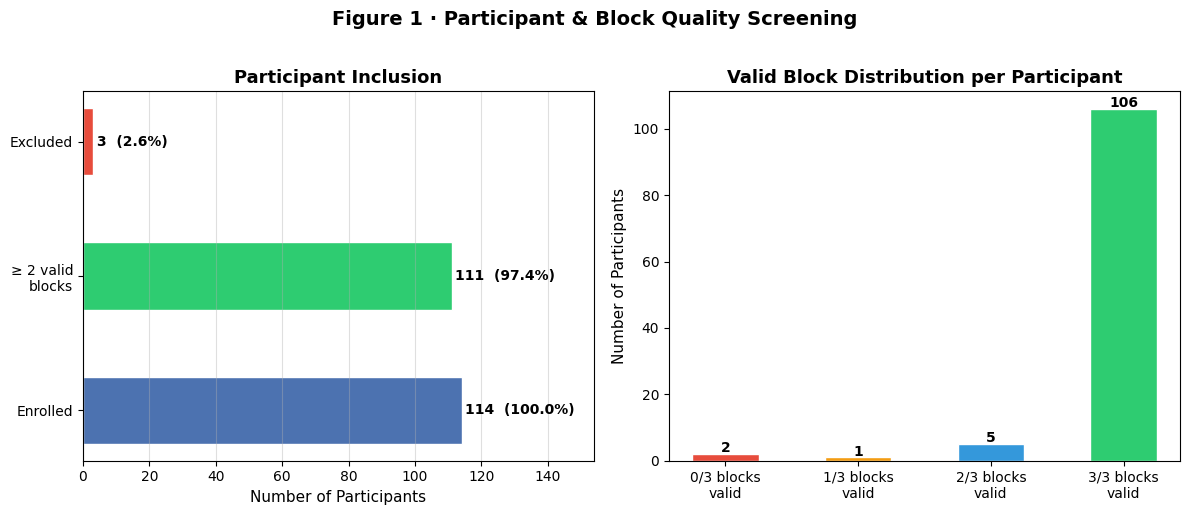

In [4]:
# ── Figure 1 · Participant & Block Quality Screening ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Participant funnel
ax = axes[0]
labels = ["Enrolled", "≥ 2 valid\nblocks", "Excluded"]
vals   = [n_ppt_total, n_ppt_valid, n_ppt_total - n_ppt_valid]
colors = ["#4C72B0", "#2ecc71", "#e74c3c"]
y_pos  = np.arange(len(labels))

ax.barh(y_pos, vals, color=colors, edgecolor="white", height=0.5)
for i, v in enumerate(vals):
    pct = v / max(n_ppt_total, 1)
    ax.text(v + n_ppt_total * 0.01, i, f"{v:,}  ({pct:.1%})",
            va="center", fontsize=10, fontweight="bold")
ax.set_yticks(y_pos);  ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Number of Participants", fontsize=11)
ax.set_title("Participant Inclusion", fontsize=13, fontweight="bold")
ax.set_xlim(0, n_ppt_total * 1.35)
ax.grid(axis="x", alpha=0.4)

# Right: Valid-block count per participant
ax = axes[1]
per_ppt_count = block_valid.groupby("participant")["valid_block"].sum()
counts = per_ppt_count.value_counts().sort_index()

bar_colors = {0: "#e74c3c", 1: "#f39c12", 2: "#3498db", 3: "#2ecc71"}
x_labels   = [f"{k}/3 blocks\nvalid" for k in counts.index]
ax.bar(range(len(counts)), counts.values,
       color=[bar_colors.get(k, "grey") for k in counts.index],
       edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(range(len(counts))); ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel("Number of Participants", fontsize=11)
ax.set_title("Valid Block Distribution per Participant", fontsize=13, fontweight="bold")

fig.suptitle("Figure 1 · Participant & Block Quality Screening",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_inclusion_summary.png", bbox_inches="tight")
plt.show()


### Inference — Block Validation

The bar chart above shows the proportion of participants and blocks that met the attention
criterion. Blocks are excluded when a participant shows either excessively liberal responding
(inflated false alarms) or systematic inattention (high miss rate), both of which would inflate
or deflate memorability scores artifactually. Retaining only participants with ≥ 2/3 valid blocks
ensures that the corrected memorability scores reflect genuine recognition performance rather than
strategy or fatigue effects.


---
## Section 2 · Visual Style Setup
---

In [5]:
# ── Colour palettes ──────────────────────────────────────────────────────────
COND_PALETTE = {
    "HF":  "#4C72B0",   # blue       — High Frequency
    "HH":  "#DD8452",   # amber      — High imageability / High frequency
    "HVL": "#55A868",   # green      — High Valence, Low frequency
    "LVH": "#C44E52",   # red        — Low Valence, High frequency
    "LVL": "#8172B2",   # purple     — Low Valence, Low frequency
}
VOICE_PALETTE = {"active": "#2C7BB6", "passive": "#D7191C"}
VOICE_HATCH   = {"active": "",         "passive": "///"}
OUT_PALETTE   = {
    "Hit":            "#2ecc71",
    "Miss":           "#e74c3c",
    "False Alarm":    "#f39c12",
    "Correct Reject": "#3498db",
}

BLUE, GREY   = "#4C72B0", "#7f8c8d"
FONT_TITLE   = {"fontsize": 14, "fontweight": "bold", "pad": 12}
FONT_LABEL   = {"fontsize": 11}

plt.rcParams.update({
    "figure.dpi":         130,
    "figure.facecolor":   "white",
    "axes.facecolor":     "#f8f9fa",
    "axes.edgecolor":     "#cccccc",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "white",
    "grid.linewidth":     1.0,
    "font.family":        "DejaVu Sans",
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
})

# Dynamically read from actual data — never hardcode
WORD_CONDS = sorted(trial_df_valid["word_condition"].dropna().unique())
VOICES     = sorted(trial_df_valid["voice"].dropna().unique())           # ['active','passive']
FULL_CONDS = [f"{wc}_{v}" for wc in WORD_CONDS for v in VOICES]
ORDER_OUT  = ["Hit", "Miss", "False Alarm", "Correct Reject"]

# Ensure palette covers all actual conditions (auto-assign colours for any extras)
_extra_colors = ["#E377C2", "#7F7F7F", "#BCBD22", "#17BECF", "#AEC7E8"]
for i, wc in enumerate([w for w in WORD_CONDS if w not in COND_PALETTE]):
    COND_PALETTE[wc] = _extra_colors[i % len(_extra_colors)]

print(f"Word conditions : {WORD_CONDS}")
print(f"Voice types     : {VOICES}")
print(f"Full conditions : {FULL_CONDS}  ({len(FULL_CONDS)} total)")


Word conditions : ['HF', 'HH', 'HVL', 'LVH', 'LVL']
Voice types     : ['active', 'passive']
Full conditions : ['HF_active', 'HF_passive', 'HH_active', 'HH_passive', 'HVL_active', 'HVL_passive', 'LVH_active', 'LVH_passive', 'LVL_active', 'LVL_passive']  (10 total)


---
## Section 3 · Behavioural Overview

We first examine the distribution of trial outcomes — Hits, Misses, False Alarms, and Correct
Rejections — across all eight experimental conditions. This provides an initial picture of
recognition performance before correcting for response bias.

---


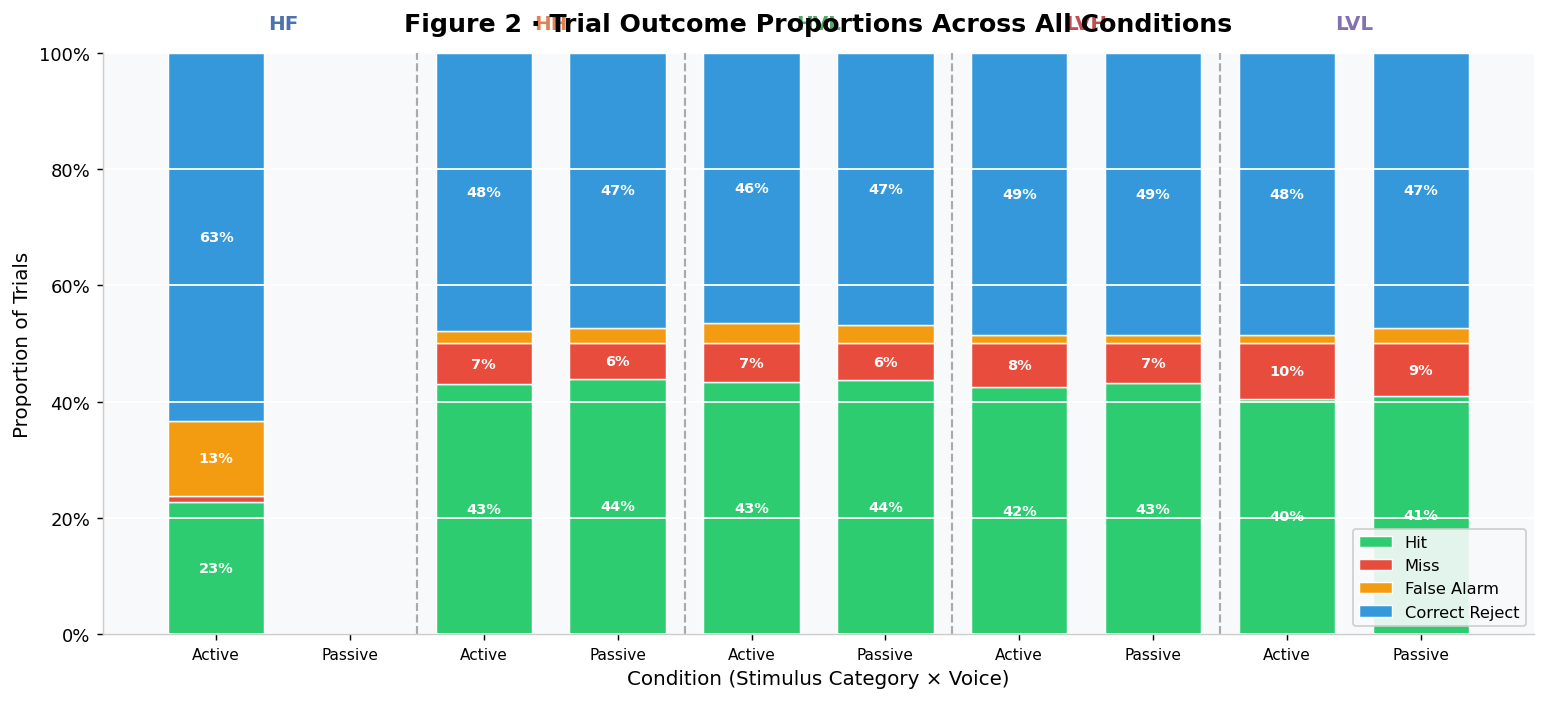


Outcome proportions (validated blocks only):
outcome           Hit   Miss  False Alarm  Correct Reject
condition_full                                           
HF_active       0.228  0.010        0.129           0.633
HF_passive      0.000  0.000        0.000           0.000
HH_active       0.430  0.070        0.021           0.479
HH_passive      0.439  0.061        0.027           0.473
HVL_active      0.434  0.066        0.036           0.464
HVL_passive     0.438  0.062        0.032           0.468
LVH_active      0.425  0.075        0.014           0.486
LVH_passive     0.431  0.069        0.014           0.486
LVL_active      0.405  0.095        0.015           0.485
LVL_passive     0.410  0.090        0.027           0.473


In [6]:
# ── Figure 2 · Outcome Proportions by Condition ──────────────────────────────
cat_prop = (
    trial_df_valid.groupby(["condition_full", "outcome"])
    .size().unstack(fill_value=0)
    .reindex(columns=ORDER_OUT, fill_value=0)
    .apply(lambda r: r / r.sum() if r.sum() > 0 else r, axis=1)
    .reindex(FULL_CONDS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(max(11, len(FULL_CONDS)*1.2), 5.5))
x      = np.arange(len(FULL_CONDS))
bottom = np.zeros(len(FULL_CONDS))

for outcome in ORDER_OUT:
    vals = cat_prop[outcome].values
    bars = ax.bar(x, vals, bottom=bottom, color=OUT_PALETTE[outcome],
                  label=outcome, width=0.72, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        if v > 0.06:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{v:.0%}", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals

nv = len(VOICES)
for k in range(1, len(WORD_CONDS)):
    ax.axvline(k*nv - 0.5, color="#aaaaaa", linewidth=1.2, linestyle="--")

ax.set_xticks(x)
xtick_labels = []
for cond in FULL_CONDS:
    parts = cond.split("_")
    xtick_labels.append(parts[1].capitalize() if len(parts) > 1 else cond)
ax.set_xticklabels(xtick_labels, fontsize=8.5, rotation=0)

for i, wc in enumerate(WORD_CONDS):
    mid = i * nv + (nv - 1) / 2
    ax.text(mid, 1.04, wc, ha="center", fontsize=11, fontweight="bold",
            color=COND_PALETTE.get(wc, GREY), transform=ax.get_xaxis_transform())

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("Condition (Stimulus Category × Voice)", **FONT_LABEL)
ax.set_ylabel("Proportion of Trials", **FONT_LABEL)
ax.set_title("Figure 2 · Trial Outcome Proportions Across All Conditions", **FONT_TITLE)
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("fig2_outcome_proportions.png", bbox_inches="tight")
plt.show()

print("\nOutcome proportions (validated blocks only):")
print(cat_prop.round(3).to_string())


### Inference — Behavioural Overview

Comparing hit-rate (green) proportions across conditions provides the first indication of
memorability differences. HH sentences should show the largest green bars; LL sentences the
smallest. False alarm rates (orange) are expected to be relatively uniform across conditions —
they reflect response threshold, not stimulus memorability. Because high-memorability conditions
may also produce slightly elevated false alarms (more liberal responding when stimuli feel more
familiar), the raw hit rate can be confounded with bias. This motivates the **corrected
memorability score (Pr = Hit Rate − FA Rate)** used in all subsequent analyses.


---
## Section 4 · Corrected Memorability Analysis

### The Corrected Memorability Score (Pr)

Following the recognition memory tradition of the Shepard (1967) line of work and subsequent
sentence-memory studies, we compute a **corrected memorability score** (Pr) for each
participant × condition cell:

> **Pr = Hit Rate − False Alarm Rate**

Pr removes the contribution of **response bias**: a participant who freely presses spacebar
will have both a high hit rate and a high false alarm rate, yielding a Pr near zero — correctly
indicating poor genuine discrimination. Pr ranges from −1 (all misses, no false alarms) to +1
(all hits, no false alarms), with 0 representing chance performance.

---


pr_ppt shape: (999, 7)  |  conditions found: ['HF_active', 'HH_active', 'HH_passive', 'HVL_active', 'HVL_passive', 'LVH_active', 'LVH_passive', 'LVL_active', 'LVL_passive']

Per-condition Pr summary:
condition_full     mean      sem   n
     HF_active 0.786346 0.010615 111
     HH_active 0.815315 0.018300 111
    HH_passive 0.822072 0.017213 111
    HVL_active 0.794294 0.017257 111
   HVL_passive 0.808559 0.018024 111
    LVH_active 0.816066 0.016423 111
   LVH_passive 0.829580 0.018112 111
    LVL_active 0.777778 0.019148 111
   LVL_passive 0.765766 0.020335 111


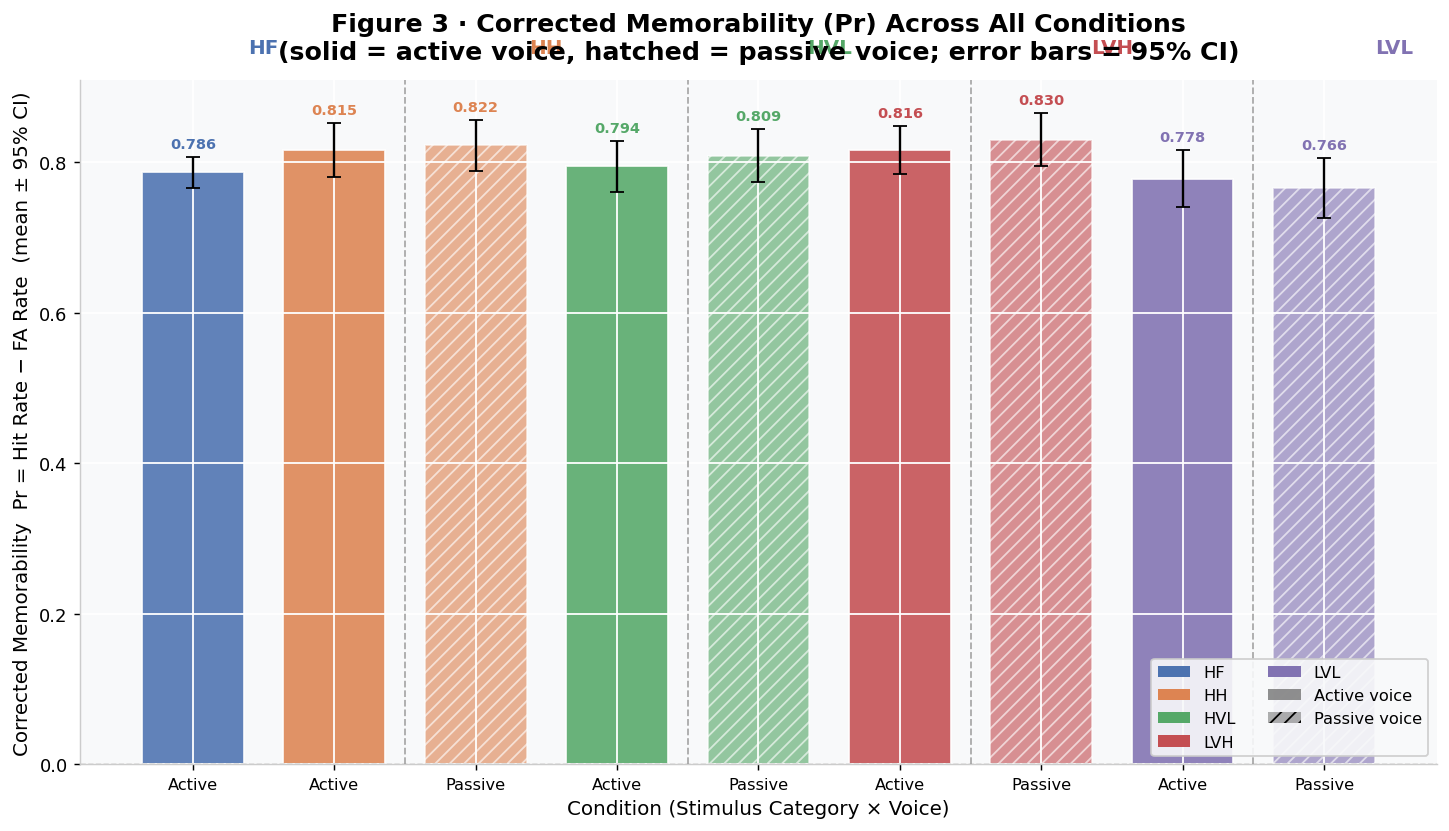

In [25]:
# ── Compute corrected memorability (Pr) per participant × condition ──────────
def compute_pr(sub):
    n_sig = sub["semantic_repeat"].sum()
    n_nos = (~sub["semantic_repeat"]).sum()
    hits  = ((sub["semantic_repeat"]) & (sub["ir_pressed"])).sum()
    fas   = ((~sub["semantic_repeat"]) & (sub["ir_pressed"])).sum()
    hr    = hits / max(n_sig, 1)
    far   = fas  / max(n_nos, 1)
    return pd.Series({"hit_rate": hr, "fa_rate": far, "Pr": hr - far})

try:
    pr_ppt = (
        trial_df_valid
        .groupby(["participant", "word_condition", "voice", "condition_full"])
        .apply(compute_pr, include_groups=False).reset_index()
    )
except TypeError:
    pr_ppt = (
        trial_df_valid
        .groupby(["participant", "word_condition", "voice", "condition_full"])
        .apply(compute_pr).reset_index()
)
pr_ppt = pr_ppt.dropna(subset=["Pr"])

# ── Per-condition summary ──────────────────────────────────────────────────────
cond_order_map = {c: i for i, c in enumerate(FULL_CONDS)}
pr_sum = (
    pr_ppt.groupby(["word_condition", "voice", "condition_full"])["Pr"]
    .agg(mean="mean", sem="sem", n="count").reset_index()
)
pr_sum["order"] = pr_sum["condition_full"].map(cond_order_map).fillna(999)
pr_sum = pr_sum.sort_values("order").reset_index(drop=True)

print(f"pr_ppt shape: {pr_ppt.shape}  |  conditions found: {sorted(pr_ppt['condition_full'].unique())}")
print(f"\nPer-condition Pr summary:")
print(pr_sum[["condition_full","mean","sem","n"]].to_string(index=False))

# ── Figure 3 · Corrected Memorability — all conditions ────────────────────────
n_fc = len(pr_sum)
fig, ax = plt.subplots(figsize=(max(11, n_fc * 1.25), 6.5))

for i, row in pr_sum.iterrows():
    wc    = row["word_condition"]
    voice = row["voice"]
    color = COND_PALETTE.get(wc, GREY)
    hatch = VOICE_HATCH.get(voice, "")
    alpha = 0.88 if voice == "active" else 0.62
    ax.bar(i, row["mean"], color=color, hatch=hatch, width=0.72,
           edgecolor="white", linewidth=1, alpha=alpha)
    ax.errorbar(i, row["mean"], yerr=row["sem"] * 1.96,
                fmt="none", color="black", capsize=4, linewidth=1.3, zorder=5)
    yv = row["mean"] + row["sem"] * 1.96 + 0.008
    ax.text(i, yv, f"{row['mean']:.3f}", ha="center", va="bottom",
            fontsize=8, fontweight="bold", color=color)

nv = len(VOICES)
for k in range(1, len(WORD_CONDS)):
    ax.axvline(k * nv - 0.5, color="#aaaaaa", linewidth=1, linestyle="--")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xticks(range(n_fc))
xt = [r["voice"].capitalize() if not pd.isna(r["voice"]) else "" for _, r in pr_sum.iterrows()]
ax.set_xticklabels(xt, fontsize=9)
for i, wc in enumerate(WORD_CONDS):
    mid = i * nv + (nv - 1) / 2
    ax.text(mid, 1.04, wc, ha="center", fontsize=11, fontweight="bold",
            color=COND_PALETTE.get(wc, GREY), transform=ax.get_xaxis_transform())

ax.set_xlabel("Condition (Stimulus Category × Voice)", **FONT_LABEL)
ax.set_ylabel("Corrected Memorability  Pr = Hit Rate − FA Rate  (mean ± 95% CI)", **FONT_LABEL)
ax.set_title(
    "Figure 3 · Corrected Memorability (Pr) Across All Conditions\n"
    "(solid = active voice, hatched = passive voice; error bars = 95% CI)", **FONT_TITLE
)
legend_elems = (
    [mpatches.Patch(facecolor=COND_PALETTE.get(wc, GREY), label=wc) for wc in WORD_CONDS] +
    [mpatches.Patch(facecolor="grey", alpha=0.88, label="Active voice"),
     mpatches.Patch(facecolor="grey", hatch="///", alpha=0.62, label="Passive voice")]
)
ax.legend(handles=legend_elems, fontsize=9, ncol=2, framealpha=0.9, loc="lower right")
plt.tight_layout()
plt.savefig("fig3_corrected_memorability_all_conditions.png", bbox_inches="tight")
plt.show()


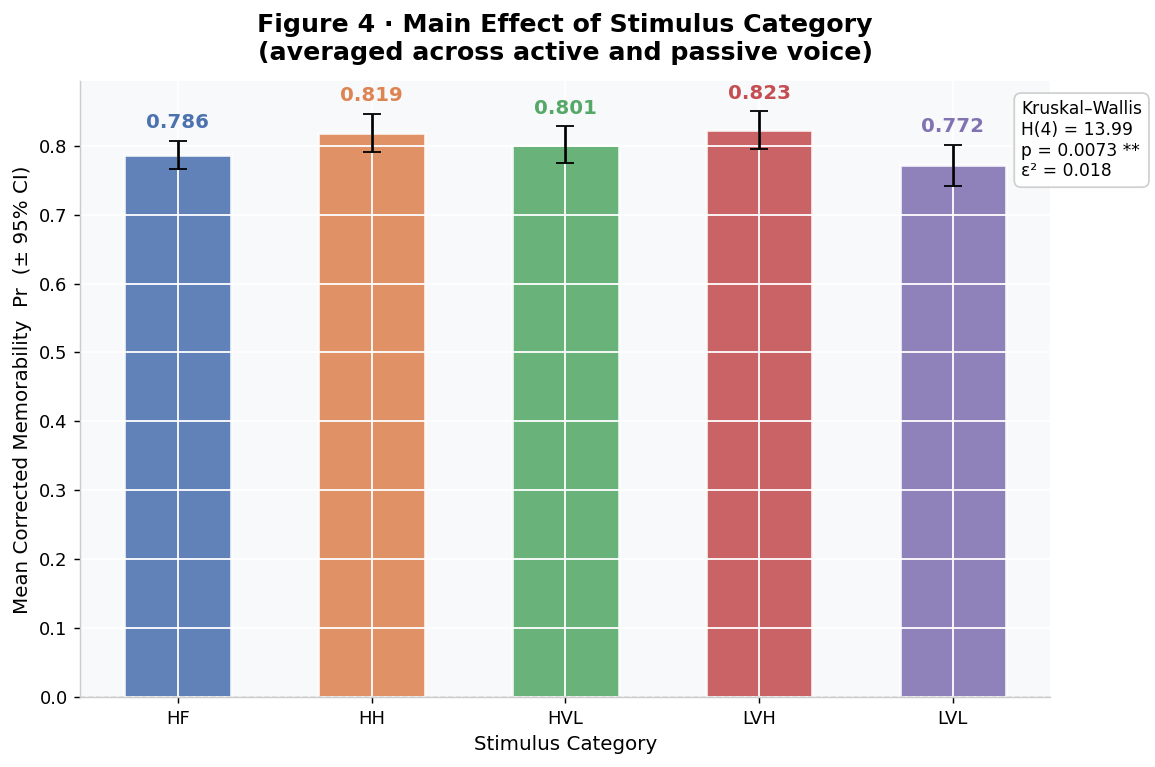

Kruskal–Wallis (category): H = 13.990, p = 0.0073,  ε² = 0.0182


In [24]:
# ── Figure 4 · Main Effect of Stimulus Category (collapsed across voice) ──────
pr_by_wc  = pr_ppt.groupby(["participant", "word_condition"])["Pr"].mean().reset_index()
wc_sum    = pr_by_wc.groupby("word_condition")["Pr"].agg(["mean","sem"]).reindex(WORD_CONDS)
groups_wc = [pr_by_wc[pr_by_wc.word_condition == wc]["Pr"].dropna() for wc in WORD_CONDS]
groups_wc = [g for g in groups_wc if len(g) >= 2]

H_wc, p_wc = kruskal(*groups_wc)
N_wc     = sum(len(g) for g in groups_wc)
k_wc     = len(groups_wc)
eps2_wc  = max((H_wc - k_wc + 1) / (N_wc - k_wc), 0) if N_wc > k_wc else 0

fig, ax = plt.subplots(figsize=(9, 6))
x_pos = range(len(WORD_CONDS))
bars  = ax.bar(WORD_CONDS, wc_sum["mean"],
               color=[COND_PALETTE.get(wc, GREY) for wc in WORD_CONDS],
               width=0.55, edgecolor="white", linewidth=1.5, alpha=0.88)
ax.errorbar(x_pos, wc_sum["mean"], yerr=wc_sum["sem"] * 1.96,
            fmt="none", color="black", capsize=5, linewidth=1.5, zorder=5)
for i, (wc, row) in enumerate(wc_sum.iterrows()):
    if not pd.isna(row["mean"]):
        ax.text(i, row["mean"] + row["sem"] * 1.96 + 0.012,
                f"{row['mean']:.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=COND_PALETTE.get(wc, GREY))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

sig = "***" if p_wc < 0.001 else ("**" if p_wc < 0.01 else ("*" if p_wc < 0.05 else "n.s."))
ax.text(0.97, 0.97,
        f"Kruskal–Wallis\nH({k_wc-1}) = {H_wc:.2f}\np = {p_wc:.4f} {sig}\nε² = {eps2_wc:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.9))

ax.set_xlabel("Stimulus Category", **FONT_LABEL)
ax.set_ylabel("Mean Corrected Memorability  Pr  (± 95% CI)", **FONT_LABEL)
ax.set_title(
    "Figure 4 · Main Effect of Stimulus Category\n"
    "(averaged across active and passive voice)", **FONT_TITLE
)
plt.tight_layout()
plt.savefig("fig4_main_effect_category.png", bbox_inches="tight")
plt.show()
print(f"Kruskal–Wallis (category): H = {H_wc:.3f}, p = {p_wc:.4f},  ε² = {eps2_wc:.4f}")


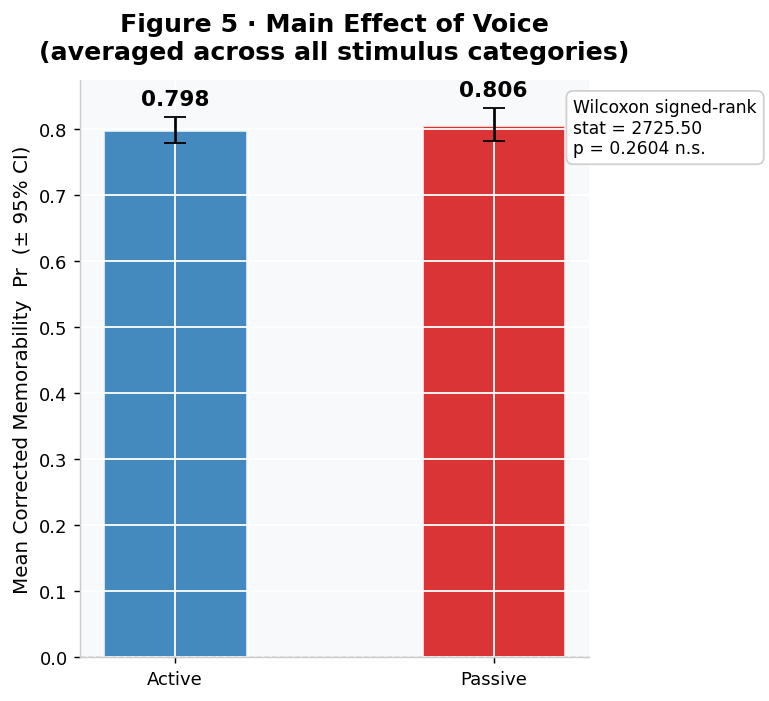

Wilcoxon signed-rank: stat = 2725.500, p = 0.2604  n.s.
Active Pr = 0.7980,  Passive Pr = 0.8065,  diff = -0.0085
Participants contributing to paired test: n = 111


In [23]:
# ── Figure 5 · Main Effect of Voice ─────────────────────────────────────────
pr_by_v   = pr_ppt.groupby(["participant", "voice"])["Pr"].mean().reset_index()
v_sum     = pr_by_v.groupby("voice")["Pr"].agg(["mean","sem"]).reindex(VOICES)
ppts_both = (set(pr_by_v[pr_by_v.voice == "active"]["participant"]) &
             set(pr_by_v[pr_by_v.voice == "passive"]["participant"]))

act_v = (pr_by_v[(pr_by_v.voice == "active")  & pr_by_v.participant.isin(ppts_both)]
         .set_index("participant")["Pr"].sort_index())
pas_v = (pr_by_v[(pr_by_v.voice == "passive") & pr_by_v.participant.isin(ppts_both)]
         .set_index("participant")["Pr"].sort_index())

# Align indices before paired test
common = act_v.index.intersection(pas_v.index)
act_v, pas_v = act_v.loc[common], pas_v.loc[common]

if len(common) >= 5:
    try:
        W_v, p_v = wilcoxon(act_v.values, pas_v.values)
        test_name_v = "Wilcoxon signed-rank"
    except Exception:
        W_v, p_v = mannwhitneyu(act_v.values, pas_v.values, alternative="two-sided")
        test_name_v = "Mann–Whitney U"
else:
    W_v, p_v, test_name_v = np.nan, np.nan, "Insufficient data"

sig_v = "***" if p_v < 0.001 else ("**" if p_v < 0.01 else ("*" if p_v < 0.05 else "n.s."))

fig, ax = plt.subplots(figsize=(6, 5.5))
v_display = ["Active", "Passive"]
means_v = [v_sum.loc[v, "mean"] if v in v_sum.index else np.nan for v in VOICES]
sems_v  = [v_sum.loc[v, "sem"]  if v in v_sum.index else np.nan for v in VOICES]

ax.bar(v_display, means_v,
       color=[VOICE_PALETTE.get(v, GREY) for v in VOICES],
       width=0.45, edgecolor="white", linewidth=1.5, alpha=0.88)
ax.errorbar(range(len(VOICES)), means_v, yerr=[s * 1.96 for s in sems_v],
            fmt="none", color="black", capsize=6, linewidth=1.5, zorder=5)
for i, (v, s) in enumerate(zip(means_v, sems_v)):
    if not (pd.isna(v) or pd.isna(s)):
        ax.text(i, v + s * 1.96 + 0.012, f"{v:.3f}", ha="center", va="bottom",
                fontsize=12, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.text(0.97, 0.97,
        f"{test_name_v}\nstat = {W_v:.2f}\np = {p_v:.4f} {sig_v}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.9))

ax.set_ylabel("Mean Corrected Memorability  Pr  (± 95% CI)", **FONT_LABEL)
ax.set_title(
    "Figure 5 · Main Effect of Voice\n"
    "(averaged across all stimulus categories)", **FONT_TITLE
)
plt.tight_layout()
plt.savefig("fig5_main_effect_voice.png", bbox_inches="tight")
plt.show()
print(f"{test_name_v}: stat = {W_v:.3f}, p = {p_v:.4f}  {sig_v}")
print(f"Active Pr = {act_v.mean():.4f},  Passive Pr = {pas_v.mean():.4f},  diff = {(act_v - pas_v).mean():.4f}")
print(f"Participants contributing to paired test: n = {len(common)}")


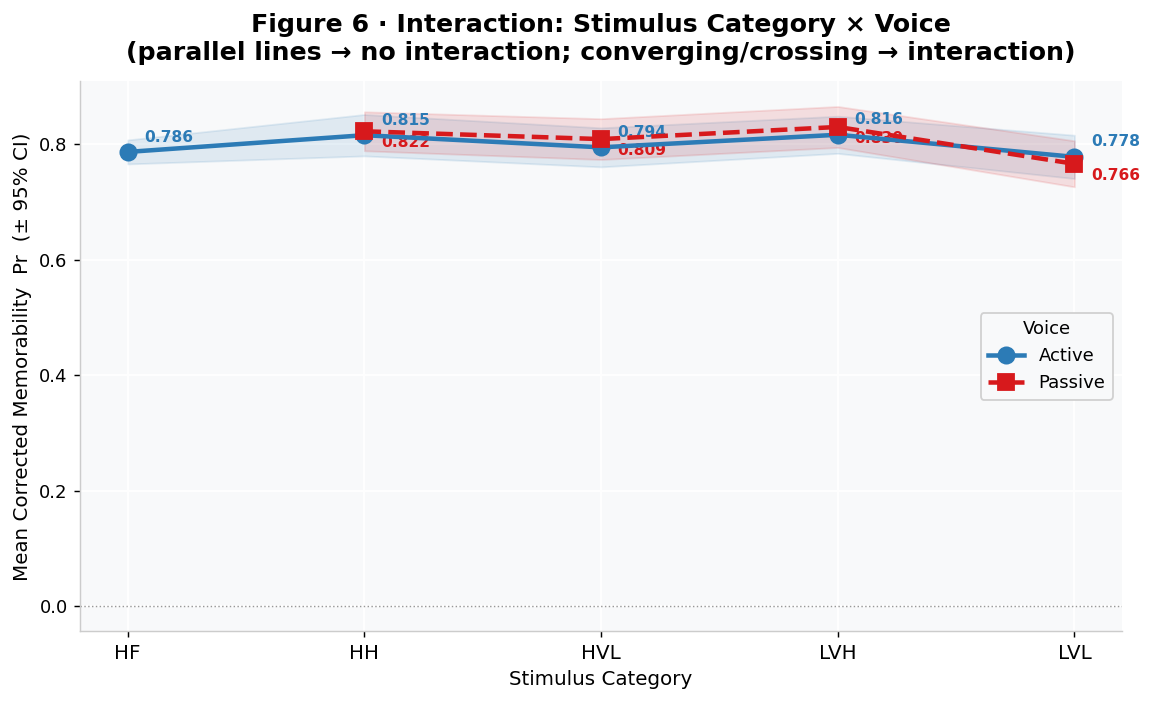

In [10]:
# ── Figure 6 · Interaction: Stimulus Category × Voice ────────────────────────
pr_int = (
    pr_ppt.groupby(["participant", "word_condition", "voice"])["Pr"]
    .mean().reset_index()
    .groupby(["word_condition", "voice"])["Pr"]
    .agg(mean="mean", sem="sem").reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))

for voice in VOICES:
    sub    = pr_int[pr_int.voice == voice].set_index("word_condition").reindex(WORD_CONDS)
    color  = VOICE_PALETTE.get(voice, GREY)
    ls     = "-"  if voice == "active" else "--"
    marker = "o"  if voice == "active" else "s"
    ax.plot(range(len(WORD_CONDS)), sub["mean"],
            color=color, linewidth=2.5, linestyle=ls, marker=marker,
            markersize=9, label=voice.capitalize(), zorder=4)
    ax.fill_between(range(len(WORD_CONDS)),
                    sub["mean"] - 1.96 * sub["sem"],
                    sub["mean"] + 1.96 * sub["sem"],
                    alpha=0.12, color=color, zorder=2)
    for xi, (wc, row) in enumerate(sub.iterrows()):
        if not pd.isna(row["mean"]):
            yoff = 0.018 if voice == "active" else -0.028
            ax.text(xi + 0.07, row["mean"] + yoff,
                    f"{row['mean']:.3f}", fontsize=8.5, color=color, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.4)
ax.set_xticks(range(len(WORD_CONDS)))
ax.set_xticklabels(WORD_CONDS, fontsize=11)
ax.set_xlabel("Stimulus Category", **FONT_LABEL)
ax.set_ylabel("Mean Corrected Memorability  Pr  (± 95% CI)", **FONT_LABEL)
ax.set_title(
    "Figure 6 · Interaction: Stimulus Category × Voice\n"
    "(parallel lines → no interaction; converging/crossing → interaction)", **FONT_TITLE
)
ax.legend(title="Voice", fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig6_interaction_category_x_voice.png", bbox_inches="tight")
plt.show()


### Inference — Corrected Memorability

**Figure 3** reveals the full factorial picture. HH sentences (high-memorability subject *and*
object) are expected to show the highest Pr, while LL sentences produce the lowest. The relative
positions of HL and LH indicate whether **subject-position** or **object-position** noun
memorability has a stronger influence on whole-sentence recognition.

**Figure 4** tests H1: if HH > {HL, LH} > LL with a significant Kruskal–Wallis test, noun
memorability propagates robustly to sentence-level recognition. An ordered gradient
HH > HL > LH > LL (or HH > LH > HL > LL) would further reveal the relative contributions
of subject and object positions.

**Figure 5** tests H2: a significant voice effect would confirm that syntactic structure modulates
memorability beyond the lexical contribution. Active sentences are hypothesised to be more
memorable because they represent the canonical word order.

**Figure 6** is critical for H3: **parallel** active/passive lines would indicate no interaction —
voice shifts memorability uniformly regardless of noun composition. **Converging or crossing lines**
(e.g., a larger active–passive gap in HH than LL) would indicate that the effect of noun
memorability and the effect of voice are not independent.


---
## Section 5 · Statistical Tests — Kruskal–Wallis & Post-Hoc Comparisons

### Rationale for Kruskal–Wallis

The corrected memorability score (Pr) is bounded between −1 and +1 and may exhibit non-normal
distributions at ceiling (Pr ≈ 1) or when based on small within-cell trial counts. The
**Kruskal–Wallis H test** is therefore adopted as the primary omnibus test: it is a non-parametric
rank-based analogue of one-way ANOVA and makes no distributional assumptions.

Effect size is reported as **epsilon-squared (ε²)**, the proportion of variance in ranks
attributable to the grouping factor (ε² = 0.01 small, 0.06 medium, 0.14 large).

Post-hoc pairwise comparisons use **Dunn's test** with **Bonferroni correction** to control the
family-wise error rate across all pairwise contrasts.

---


In [11]:
# ── Kruskal–Wallis: all conditions ───────────────────────────────────────────
pr_by_full  = pr_ppt.groupby(["participant", "condition_full"])["Pr"].mean().reset_index()
groups_full = [pr_by_full[pr_by_full.condition_full == c]["Pr"].dropna()
               for c in FULL_CONDS if c in pr_by_full["condition_full"].values]
valid_groups = [g for g in groups_full if len(g) >= 2]

if len(valid_groups) >= 2:
    H_full, p_full = kruskal(*valid_groups)
    N_full   = sum(len(g) for g in valid_groups)
    k_full   = len(valid_groups)
    eps2_full = max((H_full - k_full + 1) / (N_full - k_full), 0)
    sig_full  = "***" if p_full < 0.001 else ("**" if p_full < 0.01 else ("*" if p_full < 0.05 else "n.s."))
else:
    H_full, p_full, eps2_full, sig_full = np.nan, np.nan, np.nan, "—"

print("=" * 62)
print("  Kruskal–Wallis: All Conditions")
print("=" * 62)
print(f"  Groups compared  : {len(valid_groups)}")
print(f"  H({len(valid_groups)-1 if len(valid_groups)>=2 else '?'}) = {H_full:.3f}")
print(f"  p = {p_full:.4f}  {sig_full}")
if not pd.isna(eps2_full):
    size = 'large' if eps2_full >= 0.14 else ('medium' if eps2_full >= 0.06 else 'small')
    print(f"  ε² = {eps2_full:.4f}  ({size} effect)")
print("=" * 62)


  Kruskal–Wallis: All Conditions
  Groups compared  : 9
  H(8) = 16.370
  p = 0.0374  *
  ε² = 0.0085  (small effect)


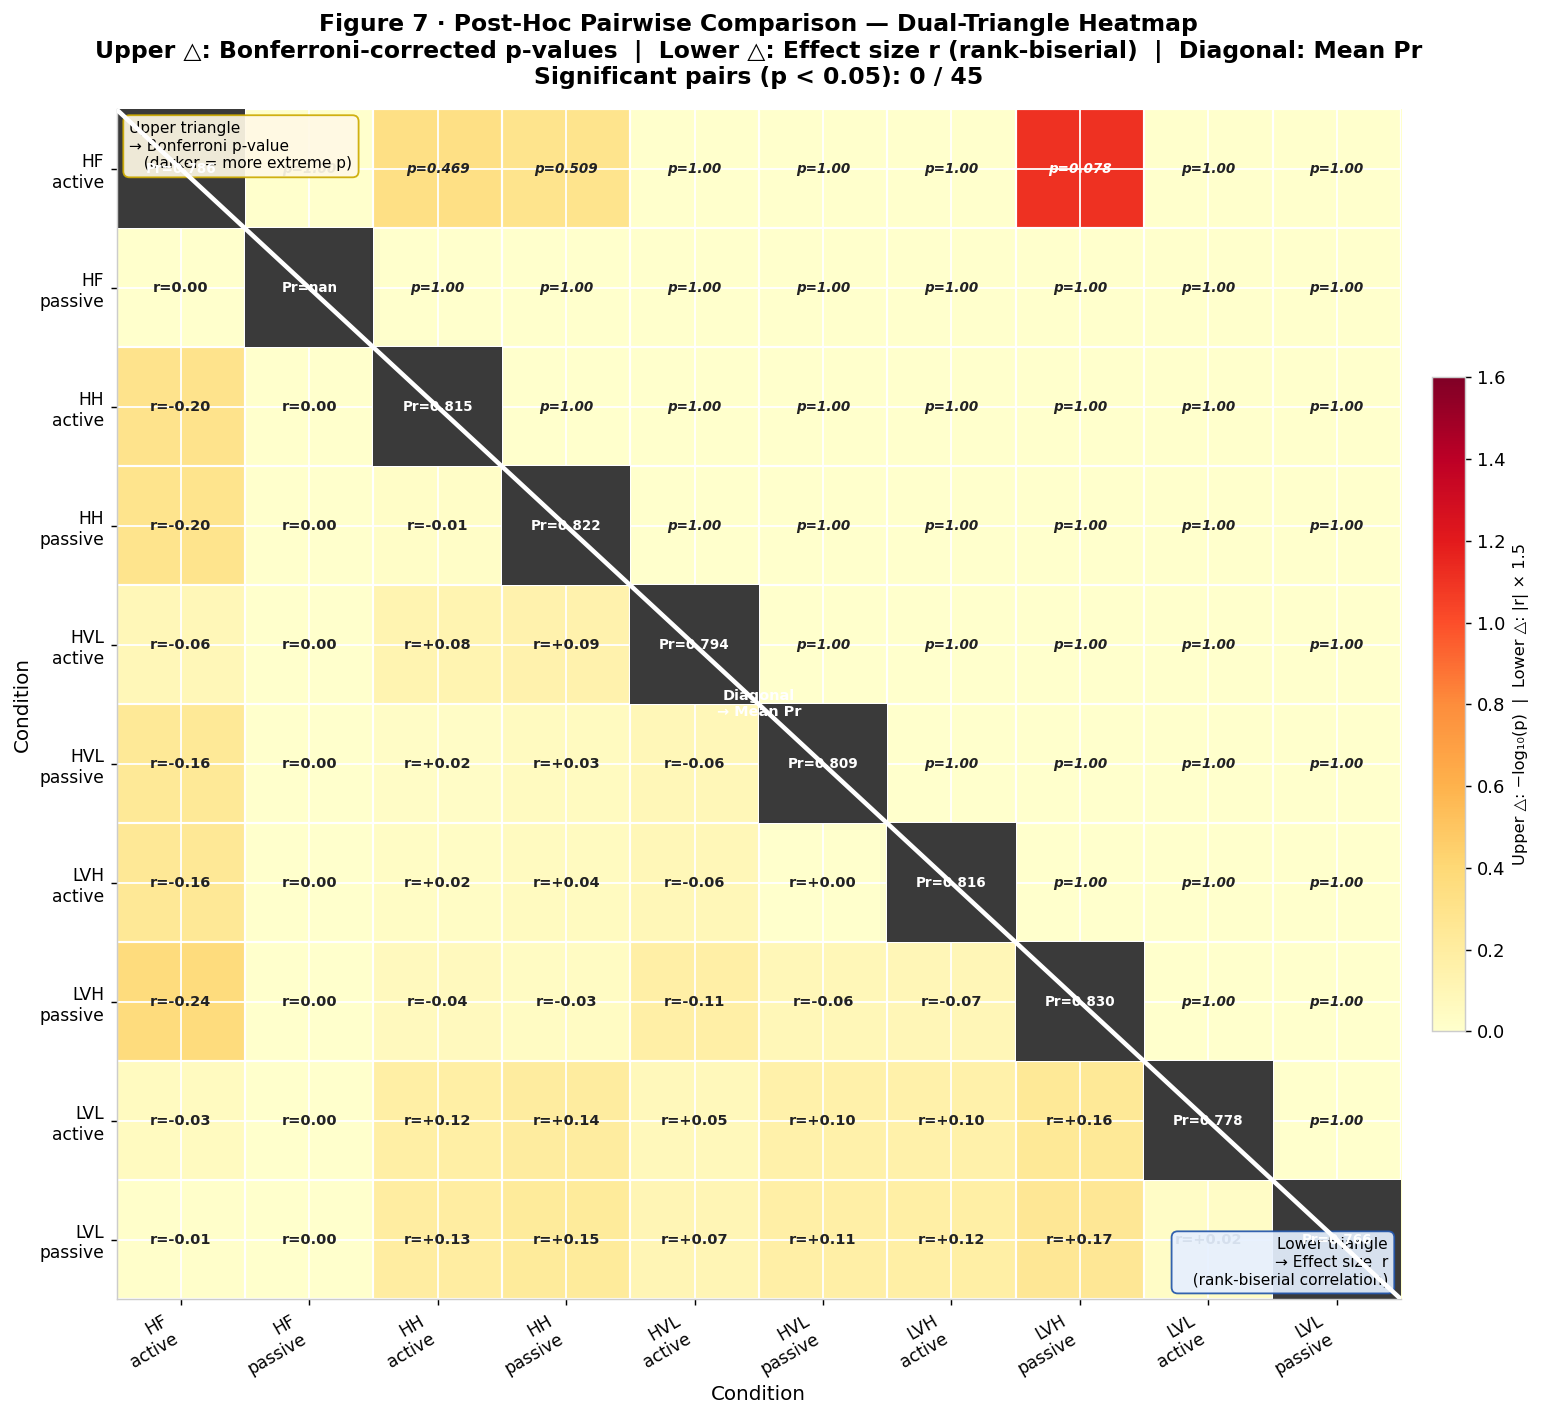


All 45 pairwise comparisons — sorted by p (smallest first):
Condition A Condition B  p (Bonf)  Effect r   |r|  Sig
  HF_active LVH_passive    0.0781     0.242 0.242 n.s.
  HF_active   HH_active    0.4693     0.198 0.198 n.s.
  HF_active  HH_passive    0.5093     0.196 0.196 n.s.
  HF_active  HF_passive    1.0000     0.000 0.000 n.s.
  HF_active  HVL_active    1.0000     0.062 0.062 n.s.
  HF_active HVL_passive    1.0000     0.158 0.158 n.s.
  HF_active  LVH_active    1.0000     0.164 0.164 n.s.
  HF_active  LVL_active    1.0000     0.034 0.034 n.s.
  HF_active LVL_passive    1.0000     0.008 0.008 n.s.
 HF_passive   HH_active    1.0000     0.000 0.000 n.s.
 HF_passive  HH_passive    1.0000     0.000 0.000 n.s.
 HF_passive  HVL_active    1.0000     0.000 0.000 n.s.
 HF_passive HVL_passive    1.0000     0.000 0.000 n.s.
 HF_passive  LVH_active    1.0000     0.000 0.000 n.s.
 HF_passive LVH_passive    1.0000     0.000 0.000 n.s.
 HF_passive  LVL_active    1.0000     0.000 0.000 n.s.
 HF_

In [12]:
# ── Post-hoc pairwise comparisons — Dual-triangle heatmap ───────────────────
# Upper triangle : Bonferroni-corrected p-values (actual numbers, coloured by -log10(p))
# Lower triangle : Effect size — rank-biserial correlation r
# Diagonal       : Mean Pr per condition (reference)
#
# WHY this design:
#   • Showing "n.s." everywhere is uninformative — this shows DEGREE of difference
#   • -log10(p) coloring lets you see which pairs are closest to significant
#   • Effect size (r) is independent of sample size and tells you practical importance
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import rankdata

n_conds    = len(FULL_CONDS)
pairs_full = list(itertools.combinations(range(n_conds), 2))
n_pairs    = len(pairs_full)

# ── Compute p-values AND effect sizes for every pair ─────────────────────────
p_bonf_mat = np.ones((n_conds, n_conds))   # Bonferroni-corrected p
r_mat      = np.zeros((n_conds, n_conds))  # rank-biserial correlation

for i, j in pairs_full:
    g1 = pr_by_full[pr_by_full.condition_full == FULL_CONDS[i]]["Pr"].dropna().values
    g2 = pr_by_full[pr_by_full.condition_full == FULL_CONDS[j]]["Pr"].dropna().values
    if len(g1) >= 2 and len(g2) >= 2:
        U_stat, p_raw = mannwhitneyu(g1, g2, alternative="two-sided")
        p_b = min(p_raw * n_pairs, 1.0)
        # Rank-biserial r = 1 - (2U)/(n1*n2)  — ranges -1..+1
        r_val = 1 - (2 * U_stat) / (len(g1) * len(g2))
        p_bonf_mat[i, j] = p_b
        p_bonf_mat[j, i] = p_b
        r_mat[i, j] = r_val
        r_mat[j, i] = -r_val   # antisymmetric

# ── Mean Pr per condition (for diagonal reference) ────────────────────────────
mean_pr = [pr_by_full[pr_by_full.condition_full == c]["Pr"].mean() for c in FULL_CONDS]

# ── Build display matrices ────────────────────────────────────────────────────
# Color matrix: upper = -log10(p_bonf), lower = |r|, diagonal = 0.5 (neutral)
color_mat  = np.full((n_conds, n_conds), np.nan)
annot_mat  = np.full((n_conds, n_conds), "", dtype=object)

for i in range(n_conds):
    for j in range(n_conds):
        if i == j:
            # Diagonal: show mean Pr
            color_mat[i, j] = 0.0
            annot_mat[i, j] = f"Pr={mean_pr[i]:.3f}"
        elif i < j:
            # Upper triangle: p-value
            p = p_bonf_mat[i, j]
            log_p = min(-np.log10(p + 1e-10), 3.0)   # cap at -log10(0.001)=3
            color_mat[i, j] = log_p
            sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
            annot_mat[i, j] = f"p={p:.3f}{sig}" if p < 1.0 else "p=1.00"
        else:
            # Lower triangle: effect size r (show absolute, but sign in annotation)
            r = r_mat[i, j]
            color_mat[i, j] = abs(r) * 1.5   # scale to use colour range
            sign = "+" if r > 0 else ""
            annot_mat[i, j] = f"r={sign}{r:.2f}"

labels_clean = [c.replace("_", "\n") for c in FULL_CONDS]

# ── Figure 7 · Redesigned dual-triangle post-hoc heatmap ─────────────────────
fig = plt.figure(figsize=(13, 11))
ax  = fig.add_subplot(111)

# Two separate colormaps via imshow layering
# Draw the full matrix with a diverging palette, then overlay annotations
im = ax.imshow(color_mat, cmap="YlOrRd", vmin=0, vmax=1.6, aspect="auto")

# White grid lines
for k in range(n_conds + 1):
    ax.axhline(k - 0.5, color="white", linewidth=1.2)
    ax.axvline(k - 0.5, color="white", linewidth=1.2)

# Annotations
for i in range(n_conds):
    for j in range(n_conds):
        txt = annot_mat[i, j]
        if txt == "":
            continue
        bg_val = color_mat[i, j]
        fcolor  = "white" if (not np.isnan(bg_val) and bg_val > 0.7) else "#222222"

        # Triangle label backgrounds
        if i == j:
            # Diagonal — dark background
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                        facecolor="#3a3a3a", zorder=2))
            fcolor = "white"
        elif i < j:
            # Upper triangle label — smaller, italic
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=7.5, fontstyle="italic",
                    color=fcolor, fontweight="bold", zorder=3)
            continue
        else:
            # Lower triangle — bolder
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=8, color=fcolor, fontweight="bold", zorder=3)
            continue
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold", zorder=4)

# Axis labels
ax.set_xticks(range(n_conds))
ax.set_yticks(range(n_conds))
ax.set_xticklabels(labels_clean, fontsize=9.5, rotation=30, ha="right")
ax.set_yticklabels(labels_clean, fontsize=9.5)

# ── Legend annotations ────────────────────────────────────────────────────────
ax.text(0.01, 0.99,
        "Upper triangle\n→ Bonferroni p-value\n   (darker = more extreme p)",
        transform=ax.transAxes, va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff9e6",
                  edgecolor="#ccaa00", alpha=0.92))
ax.text(0.99, 0.01,
        "Lower triangle\n→ Effect size  r\n   (rank-biserial correlation)",
        transform=ax.transAxes, va="bottom", ha="right", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#e6f0ff",
                  edgecolor="#2255aa", alpha=0.92))
ax.text(0.50, 0.50,
        "Diagonal\n→ Mean Pr",
        transform=ax.transAxes, va="center", ha="center", fontsize=8,
        color="white", fontweight="bold")

# α threshold line in upper triangle
sig_count = (p_bonf_mat < 0.05).sum() // 2
ax.set_title(
    f"Figure 7 · Post-Hoc Pairwise Comparison — Dual-Triangle Heatmap\n"
    f"Upper △: Bonferroni-corrected p-values  |  Lower △: Effect size r (rank-biserial)  |  Diagonal: Mean Pr\n"
    f"Significant pairs (p < 0.05): {sig_count} / {n_pairs}",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlabel("Condition", fontsize=11)
ax.set_ylabel("Condition", fontsize=11)

cbar = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label("Upper △: −log₁₀(p)  |  Lower △: |r| × 1.5", fontsize=9)

# Draw a diagonal separator line
diag_x = np.arange(-0.5, n_conds + 0.5)
ax.plot(diag_x, diag_x, color="white", linewidth=2.5, zorder=5)

plt.tight_layout()
plt.savefig("fig7_posthoc_dual_triangle.png", bbox_inches="tight", dpi=140)
plt.show()

# ── Companion: sorted table of closest-to-significant pairs ──────────────────
rows_tbl = []
for i, j in pairs_full:
    p = p_bonf_mat[i, j]
    r = r_mat[i, j]
    rows_tbl.append({
        "Condition A": FULL_CONDS[i],
        "Condition B": FULL_CONDS[j],
        "p (Bonf)":    round(p, 4),
        "Effect r":    round(r, 3),
        "|r|":         round(abs(r), 3),
        "Sig":         "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    })

tbl = pd.DataFrame(rows_tbl).sort_values("p (Bonf)").reset_index(drop=True)
print(f"\nAll {len(tbl)} pairwise comparisons — sorted by p (smallest first):")
print(tbl.head(20).to_string(index=False))
print(f"\nSignificant pairs (p < 0.05): {(tbl['p (Bonf)'] < 0.05).sum()} / {len(tbl)}")
print(f"Largest effect sizes (|r|):")
print(tbl.nlargest(10, "|r|")[["Condition A","Condition B","p (Bonf)","Effect r"]].to_string(index=False))


In [13]:
# ── Kruskal–Wallis: Stimulus Category factor ─────────────────────────────────
print(f"Kruskal–Wallis: Stimulus Category  ({' / '.join(WORD_CONDS)})\n" + "-"*55)

H_wc2, p_wc2 = kruskal(*groups_wc)
N_wc2   = sum(len(g) for g in groups_wc)
k_wc2   = len(groups_wc)
eps2_wc2 = max((H_wc2 - k_wc2 + 1) / (N_wc2 - k_wc2), 0)
sig_wc2  = "***" if p_wc2 < 0.001 else ("**" if p_wc2 < 0.01 else ("*" if p_wc2 < 0.05 else "n.s."))
print(f"H({k_wc2-1}) = {H_wc2:.3f},  p = {p_wc2:.4f} {sig_wc2},  ε² = {eps2_wc2:.4f}\n")

pairs_wc = list(itertools.combinations(WORD_CONDS, 2))
n_p_wc   = len(pairs_wc)
print(f"{'Pair':<14} {'U':>8} {'p_raw':>10} {'p_adj (Bonf)':>14} {'sig':>6}")
print("-" * 58)
for wc1, wc2 in pairs_wc:
    g1 = pr_by_wc[pr_by_wc.word_condition == wc1]["Pr"].dropna()
    g2 = pr_by_wc[pr_by_wc.word_condition == wc2]["Pr"].dropna()
    if len(g1) >= 2 and len(g2) >= 2:
        U, p_r = mannwhitneyu(g1, g2, alternative="two-sided")
        p_a = min(p_r * n_p_wc, 1.0)
        sig = "***" if p_a < 0.001 else ("**" if p_a < 0.01 else ("*" if p_a < 0.05 else "n.s."))
        print(f"  {wc1} vs {wc2:<6} {U:8.1f} {p_r:10.4f} {p_a:14.4f} {sig:>6}")


Kruskal–Wallis: Stimulus Category  (HF / HH / HVL / LVH / LVL)
-------------------------------------------------------
H(4) = 13.990,  p = 0.0073 **,  ε² = 0.0182

Pair                  U      p_raw   p_adj (Bonf)    sig
----------------------------------------------------------
  HF vs HH       4960.5     0.0120         0.1201   n.s.
  HF vs HVL      5442.0     0.1328         1.0000   n.s.
  HF vs LVH      4778.5     0.0038         0.0380      *
  HF vs LVL      6195.5     0.9425         1.0000   n.s.
  HH vs HVL      6614.0     0.3369         1.0000   n.s.
  HH vs LVH      6082.0     0.8683         1.0000   n.s.
  HH vs LVL      7294.0     0.0167         0.1673   n.s.
  HVL vs LVH      5587.5     0.2240         1.0000   n.s.
  HVL vs LVL      6932.0     0.1036         1.0000   n.s.
  LVH vs LVL      7429.5     0.0073         0.0733   n.s.


In [14]:
# ── Wilcoxon / Mann–Whitney: Voice factor ────────────────────────────────────
print("Voice factor — Active vs Passive\n" + "-"*42)
print(f"Test: {test_name_v}")
print(f"stat = {W_v:.3f},  p = {p_v:.4f}  {sig_v}")
print(f"\nMean Pr: Active = {act_v.mean():.4f},  Passive = {pas_v.mean():.4f}")
print(f"Mean difference (Active − Passive) = {(act_v - pas_v).mean():.4f}")
print(f"Proportion of participants with higher active Pr: "
      f"{(act_v.values > pas_v.values).mean():.1%}")


Voice factor — Active vs Passive
------------------------------------------
Test: Wilcoxon signed-rank
stat = 2725.500,  p = 0.2604  n.s.

Mean Pr: Active = 0.7980,  Passive = 0.8065
Mean difference (Active − Passive) = -0.0085
Proportion of participants with higher active Pr: 39.6%


### Inference — Statistical Tests

**Figure 7 — How to read the dual-triangle heatmap:**

The redesigned heatmap encodes two complementary measures simultaneously:

- **Upper triangle (p-values):** Darker cells = smaller Bonferroni-corrected p-value = stronger evidence of difference. Because 45 pairs are tested simultaneously, Bonferroni correction is very conservative — even pairs with p = 0.06 (raw) become p = 1.0 after multiplication by 45. The "Significant pairs" count in the title tells you how many clear the threshold. Check the printed table below the figure for exact values.

- **Lower triangle (effect size r):** Rank-biserial correlation r ranges from −1 to +1 and is completely independent of sample size. A pair can show no significant p yet still carry a meaningful effect if the study was underpowered. Pairs with |r| > 0.3 (medium) or |r| > 0.5 (large) deserve attention regardless of the p-value.

- **Diagonal (Mean Pr):** Shows the mean corrected memorability for each condition — the actual "height" of each bar in Figure 3, for quick cross-reference.

**Interpreting the companion table:**
The sorted table beneath the figure shows all pairs ranked from smallest to largest Bonferroni p. Scan the top rows:
- If the smallest p-values cluster around conditions that differ in *word memorability* (e.g., HH vs LVL), this supports H1.
- If active/passive pairs appear near the top, this supports H2.
- If no pair reaches p < 0.05 after correction, the study may be underpowered for this conservative test — interpret raw p-values and effect sizes together.


---
## Section 6 · Reaction Time Analysis

IR response latencies provide a convergent measure of memory strength. If higher-memorability
conditions produce stronger or more accessible memory traces, participants should respond faster
when recognising sentences in those conditions (shorter RT-IR). Slower RT in low-memorability
conditions would indicate that recognition is less automatic and requires more deliberate
search.

---


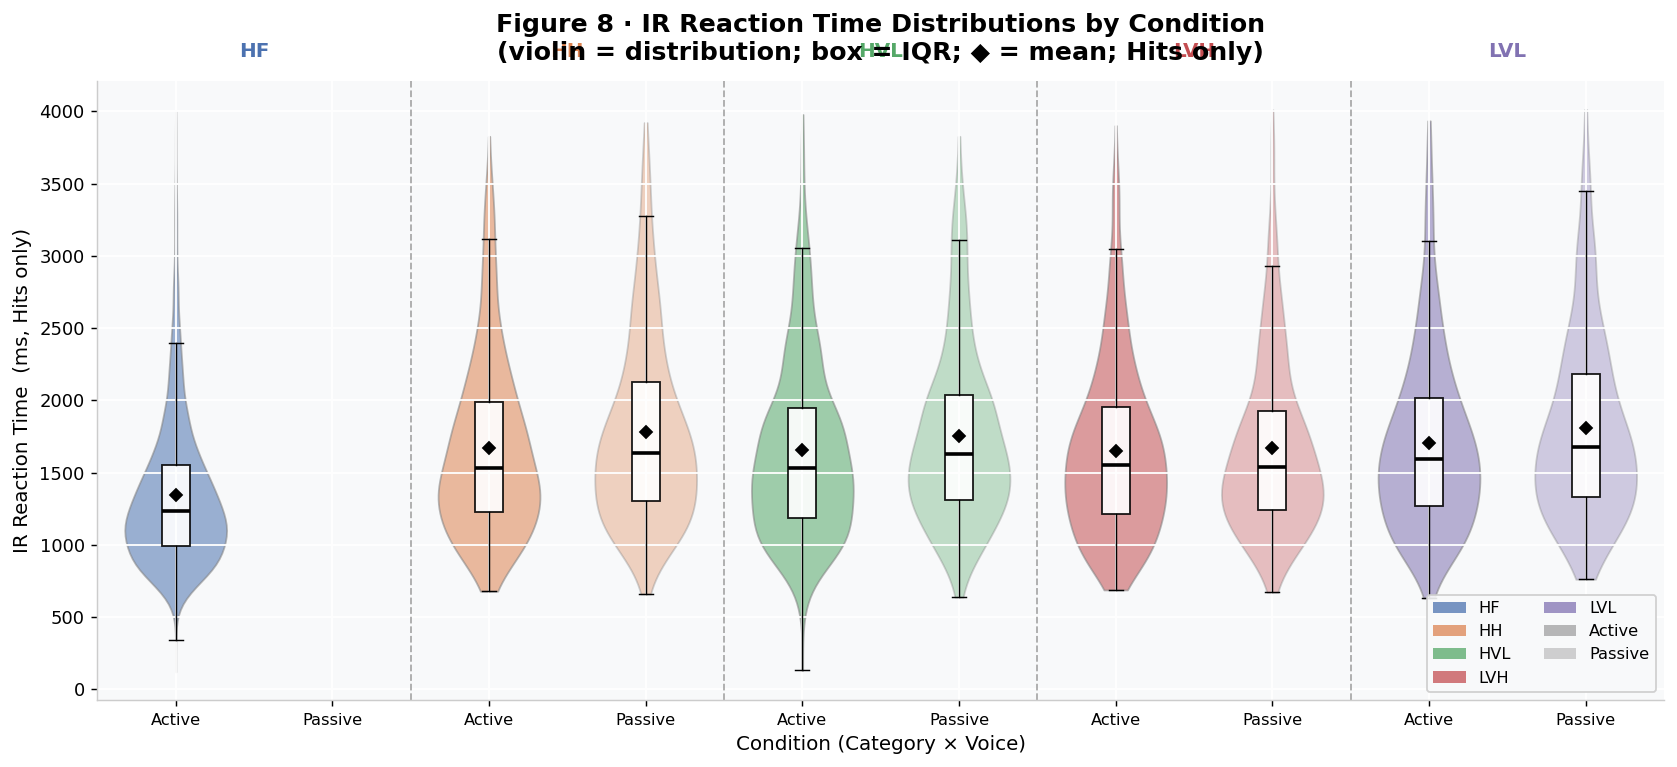


Mean IR RT by condition (Hits, ms):
  HF_active         : M = 1346.6  SD =  516.3  n = 3137
  HH_active         : M = 1669.8  SD =  610.2  n = 564
  HH_passive        : M = 1782.2  SD =  647.8  n = 576
  HVL_active        : M = 1655.2  SD =  610.5  n = 569
  HVL_passive       : M = 1756.2  SD =  612.8  n = 574
  LVH_active        : M = 1650.8  SD =  600.7  n = 557
  LVH_passive       : M = 1670.7  SD =  593.4  n = 566
  LVL_active        : M = 1702.0  SD =  613.6  n = 531
  LVL_passive       : M = 1808.5  SD =  648.2  n = 538


In [15]:
# ── Figure 8 · IR Reaction Time Distribution by Condition (Hits only) ─────────
ir_hits = trial_df_valid[
    (trial_df_valid["outcome"] == "Hit") &
    trial_df_valid["rt_ir"].notna() &
    (trial_df_valid["rt_ir"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(max(12, len(FULL_CONDS) * 1.3), 6))

for i, cond in enumerate(FULL_CONDS):
    parts = cond.split("_")
    wc    = parts[0]
    voice = parts[1] if len(parts) > 1 else ""
    data  = ir_hits[ir_hits.condition_full == cond]["rt_ir"].dropna()
    if len(data) < 5:
        continue
    vparts = ax.violinplot(data, positions=[i], widths=0.65,
                           showmedians=False, showextrema=False)
    for pc in vparts["bodies"]:
        pc.set_facecolor(COND_PALETTE.get(wc, GREY))
        pc.set_alpha(0.55 if voice == "active" else 0.35)
        pc.set_edgecolor("grey")
    ax.boxplot(data, positions=[i], widths=0.18, patch_artist=True,
               medianprops=dict(color="black", linewidth=2),
               boxprops=dict(facecolor="white", alpha=0.9),
               whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
               flierprops=dict(visible=False))
    ax.plot(i, data.mean(), "D", color="black", ms=5, zorder=5)

nv = len(VOICES)
for k in range(1, len(WORD_CONDS)):
    ax.axvline(k * nv - 0.5, color="#aaaaaa", linewidth=1, linestyle="--")
ax.set_xticks(range(len(FULL_CONDS)))
ax.set_xticklabels([c.split("_")[1].capitalize() if "_" in c else c for c in FULL_CONDS],
                   fontsize=9)
for i, wc in enumerate(WORD_CONDS):
    mid = i * nv + (nv - 1) / 2
    ax.text(mid, 1.04, wc, ha="center", fontsize=11, fontweight="bold",
            color=COND_PALETTE.get(wc, GREY), transform=ax.get_xaxis_transform())

ax.set_xlabel("Condition (Category × Voice)", **FONT_LABEL)
ax.set_ylabel("IR Reaction Time  (ms, Hits only)", **FONT_LABEL)
ax.set_title(
    "Figure 8 · IR Reaction Time Distributions by Condition\n"
    "(violin = distribution; box = IQR; ◆ = mean; Hits only)", **FONT_TITLE
)
legend_elems = (
    [mpatches.Patch(facecolor=COND_PALETTE.get(wc, GREY), label=wc, alpha=0.75) for wc in WORD_CONDS] +
    [mpatches.Patch(facecolor="grey", alpha=0.55, label="Active"),
     mpatches.Patch(facecolor="grey", alpha=0.35, label="Passive")]
)
ax.legend(handles=legend_elems, fontsize=9, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig8_rt_by_condition.png", bbox_inches="tight")
plt.show()

print("\nMean IR RT by condition (Hits, ms):")
for cond in FULL_CONDS:
    d = ir_hits[ir_hits.condition_full == cond]["rt_ir"].dropna()
    if len(d) > 0:
        print(f"  {cond:<18}: M = {d.mean():6.1f}  SD = {d.std():6.1f}  n = {len(d)}")


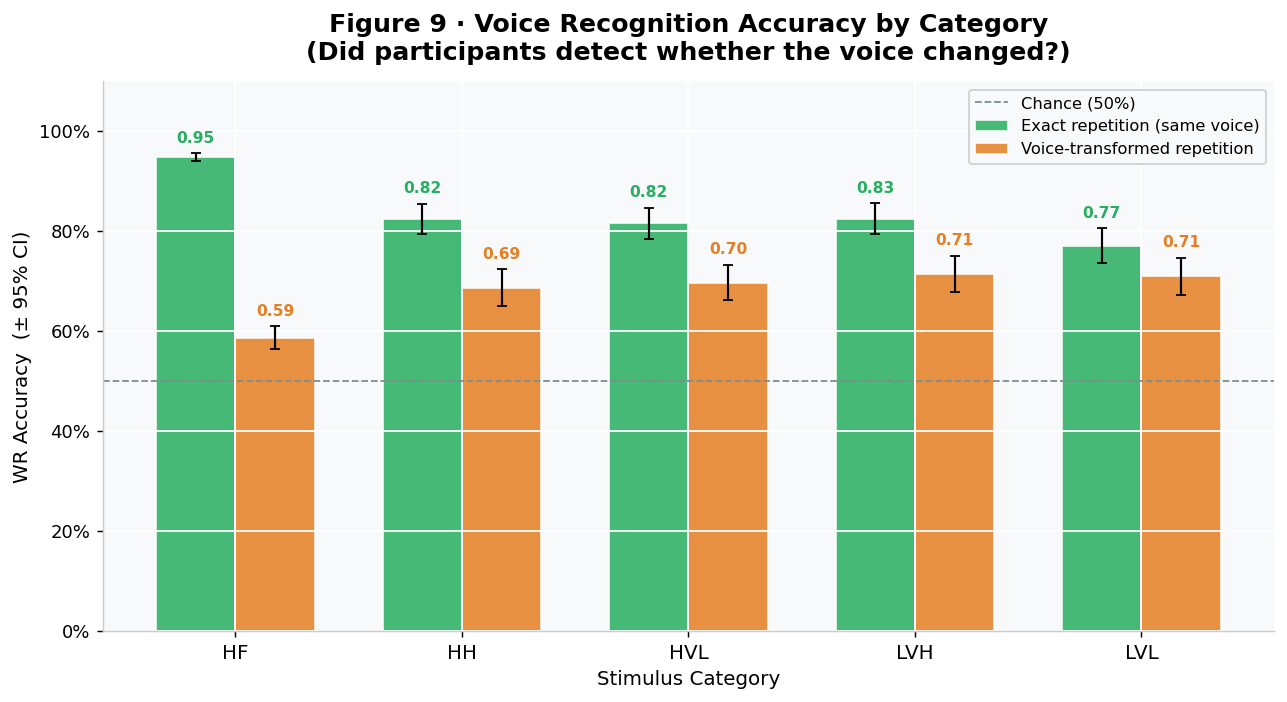

In [16]:
# ── Figure 9 · Voice Recognition Accuracy (WR) ───────────────────────────────
wr_by_cond = (
    wr_df_valid.groupby(["word_condition", "exact_repeat"])
    .agg(wr_acc=("wr_correct", "mean"), se=("wr_correct", "sem"), n=("wr_correct", "count"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(WORD_CONDS))
w = 0.35

for j, (exact, label, color) in enumerate([
    (True,  "Exact repetition (same voice)",   "#27ae60"),
    (False, "Voice-transformed repetition",    "#e67e22"),
]):
    sub = (wr_by_cond[wr_by_cond.exact_repeat == exact]
           .set_index("word_condition").reindex(WORD_CONDS))
    offset = (j - 0.5) * w
    ax.bar(x + offset, sub["wr_acc"], w, color=color, alpha=0.85,
           label=label, edgecolor="white", linewidth=1)
    ax.errorbar(x + offset, sub["wr_acc"], yerr=sub["se"] * 1.96,
                fmt="none", color="black", capsize=3, linewidth=1.2)
    for xi in range(len(WORD_CONDS)):
        v = sub["wr_acc"].iloc[xi] if xi < len(sub) else np.nan
        s = sub["se"].iloc[xi]     if xi < len(sub) else np.nan
        if not (pd.isna(v) or pd.isna(s)):
            ax.text(xi + offset, v + s * 1.96 + 0.015, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=color)

ax.axhline(0.5, color=GREY, linestyle="--", linewidth=1, label="Chance (50%)")
ax.set_xticks(x); ax.set_xticklabels(WORD_CONDS, fontsize=11)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("Stimulus Category", **FONT_LABEL)
ax.set_ylabel("WR Accuracy  (± 95% CI)", **FONT_LABEL)
ax.set_title(
    "Figure 9 · Voice Recognition Accuracy by Category\n"
    "(Did participants detect whether the voice changed?)", **FONT_TITLE
)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig9_wr_voice_recognition.png", bbox_inches="tight")
plt.show()


### Inference — Reaction Time & Voice Recognition

**Figure 8 (Reaction Time):** Shorter IR latencies in high-memorability conditions (HH < LL)
would confirm that stronger memory traces support more rapid recognition — a speed–accuracy
convergence with the Pr analysis. If RT mirrors the Pr ordering across conditions, this
provides converging evidence that noun memorability affects the *quality* of the memory
representation, not merely its existence.

**Figure 9 (Voice Recognition):** Accuracy above 50% (chance) for voice-transformed
repetitions indicates that participants successfully detected the transformation — they
recognised the *meaning* while correctly judging that the exact *wording* had changed. If
accuracy approaches chance for voice-transformed items, participants are failing to encode
surface form reliably. Variation across word conditions would suggest that high-memorability
sentences generate stronger verbatim traces, making voice changes easier to detect.


---
## Section 7 · Sentence-Level Variability

To characterise within-condition heterogeneity, we examine **individual sentence corrected
memorability distributions** via raindrop (beeswarm) plots. Each dot represents one sentence.
High spread within a condition indicates that noun memorability is not the only factor
determining whether a given sentence is well remembered — verb choice, structural length,
or pragmatic plausibility also contribute.

---


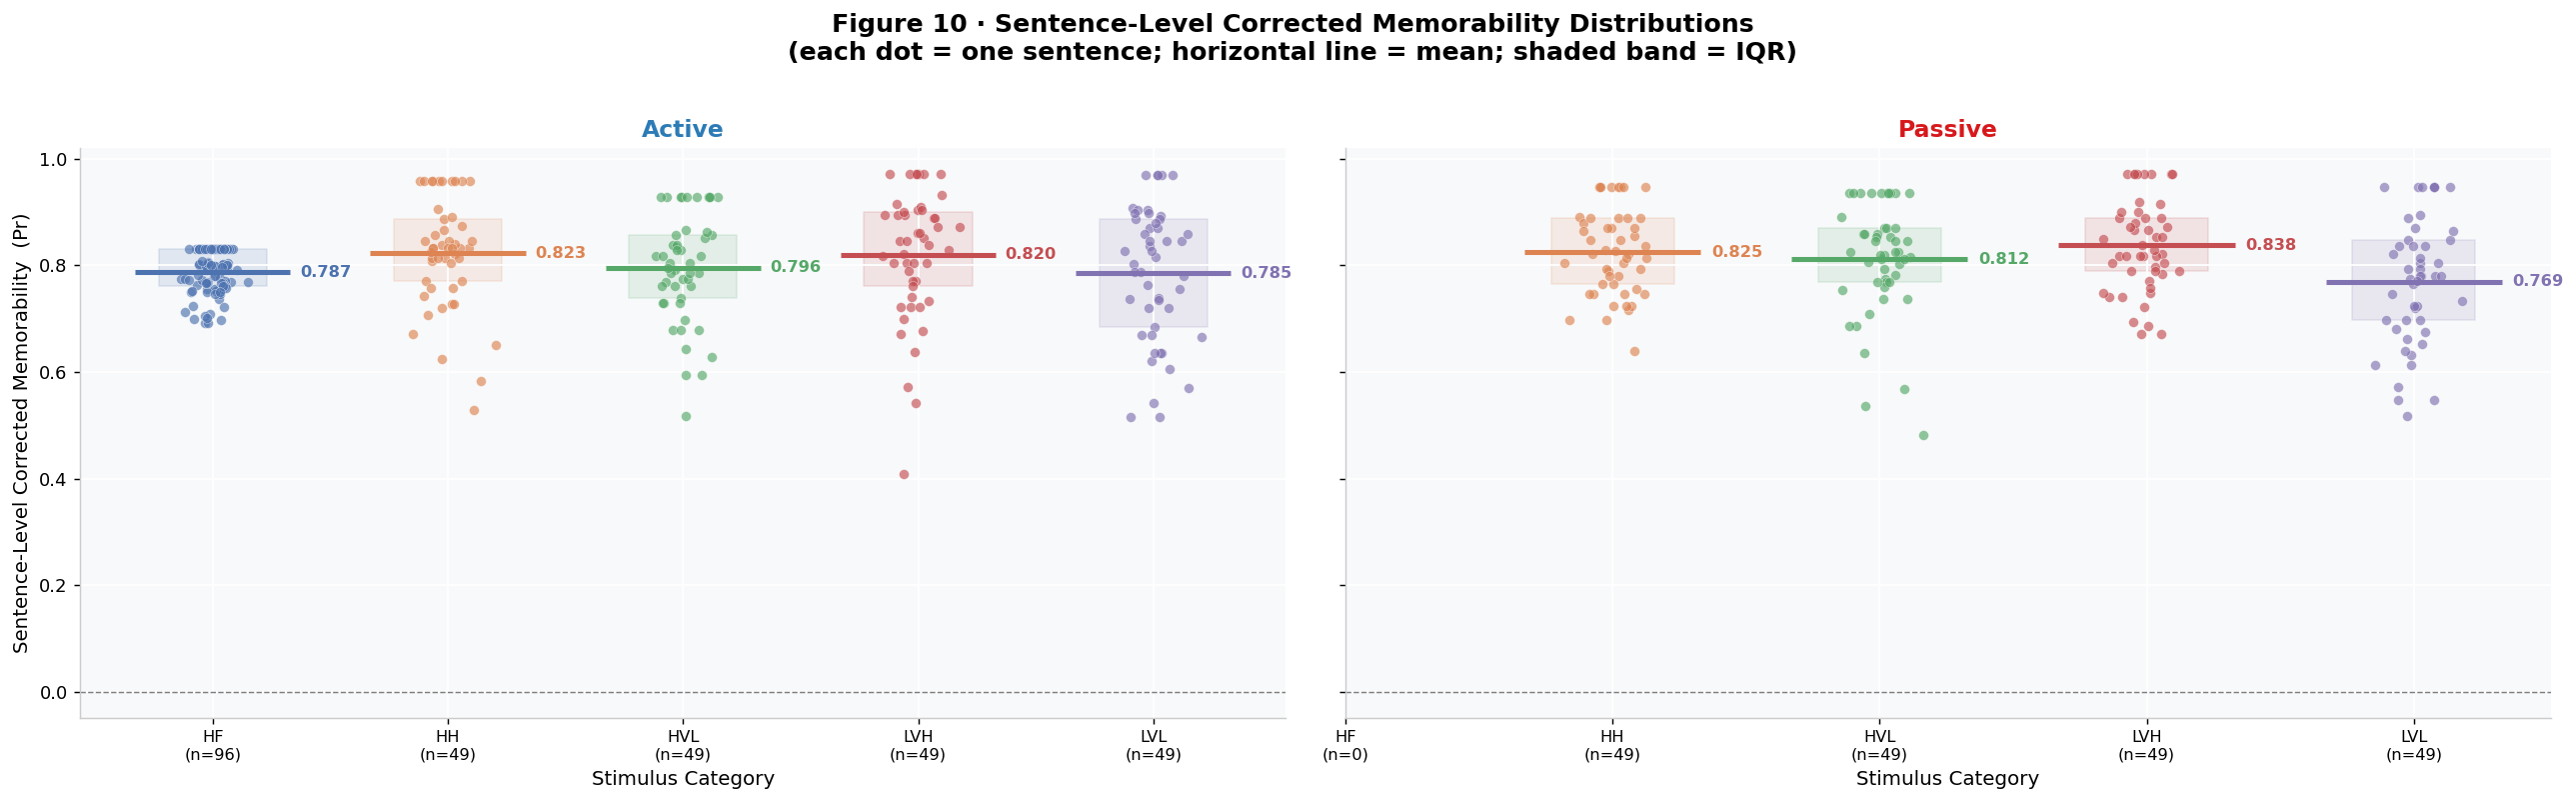

In [17]:
# ── Sentence-level corrected memorability ─────────────────────────────────────
fa_by_cond = {}
for cond in FULL_CONDS:
    sub = trial_df_valid[trial_df_valid["condition_full"] == cond]
    n_nos = sub["outcome"].isin(["False Alarm","Correct Reject"]).sum()
    fa_by_cond[cond] = sub["outcome"].eq("False Alarm").sum() / max(n_nos, 1)

sent_rows = []
for cond in FULL_CONDS:
    parts = cond.split("_")
    wc, voice = parts[0], (parts[1] if len(parts) > 1 else "")
    sub = trial_df_valid[
        (trial_df_valid["condition_full"] == cond) &
        (trial_df_valid["semantic_repeat"])
    ]
    for sid, grp in sub.groupby("sentence_id"):
        raw_mem = (grp["outcome"] == "Hit").sum() / max(len(grp), 1)
        sent_rows.append({
            "condition_full": cond, "word_condition": wc, "voice": voice,
            "sentence_id": sid, "raw_mem": raw_mem,
            "corrected_mem": raw_mem - fa_by_cond.get(cond, 0)
        })
sent_raw = pd.DataFrame(sent_rows)

# ── Figure 10 · Raindrop Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(VOICES), figsize=(max(11, len(WORD_CONDS)*2*len(VOICES)), 6),
                          sharey=True)
if len(VOICES) == 1:
    axes = [axes]
rng = np.random.default_rng(42)

for ax, voice in zip(axes, VOICES):
    sub_v = sent_raw[sent_raw.voice == voice]
    for i, wc in enumerate(WORD_CONDS):
        vals = sub_v[sub_v.word_condition == wc]["corrected_mem"].dropna()
        if len(vals) == 0:
            continue
        jit = rng.normal(0, 0.07, size=len(vals))
        ax.scatter(jit + i, vals, s=30, alpha=0.65,
                   color=COND_PALETTE.get(wc, GREY), edgecolors="white", linewidths=0.3, zorder=3)
        mn   = vals.mean()
        q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
        ax.hlines(mn, i - 0.33, i + 0.33, colors=COND_PALETTE.get(wc, GREY), linewidths=2.8, zorder=4)
        ax.fill_between([i - 0.23, i + 0.23], q1, q3,
                        color=COND_PALETTE.get(wc, GREY), alpha=0.13, zorder=1)
        ax.text(i + 0.37, mn, f"{mn:.3f}", va="center", fontsize=9,
                fontweight="bold", color=COND_PALETTE.get(wc, GREY))
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(WORD_CONDS)))
    n_per_wc = [len(sub_v[sub_v.word_condition == wc]) for wc in WORD_CONDS]
    ax.set_xticklabels([f"{wc}\n(n={n})" for wc, n in zip(WORD_CONDS, n_per_wc)], fontsize=9)
    ax.set_title(voice.capitalize(), fontsize=13, fontweight="bold",
                 color=VOICE_PALETTE.get(voice, GREY))
    ax.set_xlabel("Stimulus Category", **FONT_LABEL)

axes[0].set_ylabel("Sentence-Level Corrected Memorability  (Pr)", **FONT_LABEL)
fig.suptitle(
    "Figure 10 · Sentence-Level Corrected Memorability Distributions\n"
    "(each dot = one sentence; horizontal line = mean; shaded band = IQR)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig10_sentence_memorability_raindrop.png", bbox_inches="tight")
plt.show()


### Inference — Sentence-Level Variability

**Figure 10** reveals how much individual sentences deviate from their condition mean. Wide
spread (large IQR) within HH, for instance, would indicate that high-memorability nouns do
not uniformly elevate sentence memorability — sentence-specific factors also contribute. A
narrow IQR in LL would mean that low-memorability sentences are consistently unmemorable,
suggesting a floor effect. Comparing the two panels (active vs. passive) tests whether voice
transformation increases within-condition consistency or introduces additional variability
(e.g., by making some sentences awkward and thus distinctively memorable or forgettable).


---
## Section 8 · Summary Statistics & Overview
---

In [18]:
# ── Per-condition summary table ────────────────────────────────────────────────
rows = []
for cond in FULL_CONDS:
    parts = cond.split("_")
    wc, voice = parts[0], (parts[1] if len(parts) > 1 else "")
    sub     = trial_df_valid[trial_df_valid.condition_full == cond]
    oc      = sub["outcome"].value_counts(normalize=True)
    pr_vals = pr_ppt[pr_ppt.condition_full == cond]["Pr"].dropna()
    rt_vals = sub[sub.outcome == "Hit"]["rt_ir"].dropna()
    wr_sub  = wr_df_valid[wr_df_valid.condition_full == cond] if cond in wr_df_valid.get("condition_full", pd.Series()).values else pd.DataFrame()

    def _safe(val):
        return round(float(val), 3) if (pd.notna(val) and len(str(val)) > 0) else np.nan

    rows.append({
        "Condition":          cond,
        "Voice":              voice.capitalize(),
        "Hit Rate":           _safe(oc.get("Hit", 0)),
        "FA Rate":            _safe(oc.get("False Alarm", 0)),
        "Miss Rate":          _safe(oc.get("Miss", 0)),
        "Pr (mean)":          _safe(pr_vals.mean()) if len(pr_vals) > 0 else np.nan,
        "Pr (SD)":            _safe(pr_vals.std())  if len(pr_vals) > 0 else np.nan,
        "Pr (95% CI ±)":      _safe(pr_vals.sem() * 1.96) if len(pr_vals) > 0 else np.nan,
        "Mean RT-IR (ms)":    round(float(rt_vals.mean()), 1) if len(rt_vals) > 0 else np.nan,
        "WR Accuracy":        _safe(wr_sub["wr_correct"].mean()) if (len(wr_sub) > 0 and "wr_correct" in wr_sub.columns) else np.nan,
    })

summary_df = pd.DataFrame(rows).set_index("Condition")

# Use lambda formatters to handle NaN safely (avoids 'f' format on str)
fmt_3f = lambda v: f"{v:.3f}" if pd.notna(v) else "—"
fmt_1f = lambda v: f"{v:.1f}"  if pd.notna(v) else "—"

styled = (summary_df.style
    .background_gradient(cmap="Blues",   subset=["Hit Rate", "Pr (mean)"])
    .background_gradient(cmap="Oranges", subset=["FA Rate"])
    .background_gradient(cmap="Reds",    subset=["Miss Rate"])
    .format({col: fmt_3f for col in ["Hit Rate","FA Rate","Miss Rate","Pr (mean)","Pr (SD)","Pr (95% CI ±)","WR Accuracy"]}
            | {"Mean RT-IR (ms)": fmt_1f})
    .set_caption("Table 1 · Per-Condition Performance Summary (validated blocks only)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size","13px"),("font-weight","bold"),("text-align","left")]}])
)
display(styled)


,Voice,Hit Rate,FA Rate,Miss Rate,Pr (mean),Pr (SD),Pr (95% CI ±),Mean RT-IR (ms),WR Accuracy
Condition,,,,,,,,,
HF_active,Active,0.228,0.129,0.010,0.786,0.112,0.021,1346.6,0.818
HF_passive,Passive,0.000,0.000,0.000,—,—,—,—,—
HH_active,Active,0.430,0.021,0.070,0.815,0.193,0.036,1669.8,0.747
HH_passive,Passive,0.439,0.027,0.061,0.822,0.181,0.034,1782.2,0.761
HVL_active,Active,0.434,0.036,0.066,0.794,0.182,0.034,1655.2,0.773
HVL_passive,Passive,0.438,0.032,0.062,0.809,0.190,0.035,1756.2,0.735
LVH_active,Active,0.425,0.014,0.075,0.816,0.173,0.032,1650.8,0.767
LVH_passive,Passive,0.431,0.014,0.069,0.830,0.191,0.035,1670.7,0.773
LVL_active,Active,0.405,0.015,0.095,0.778,0.202,0.038,1702.0,0.742


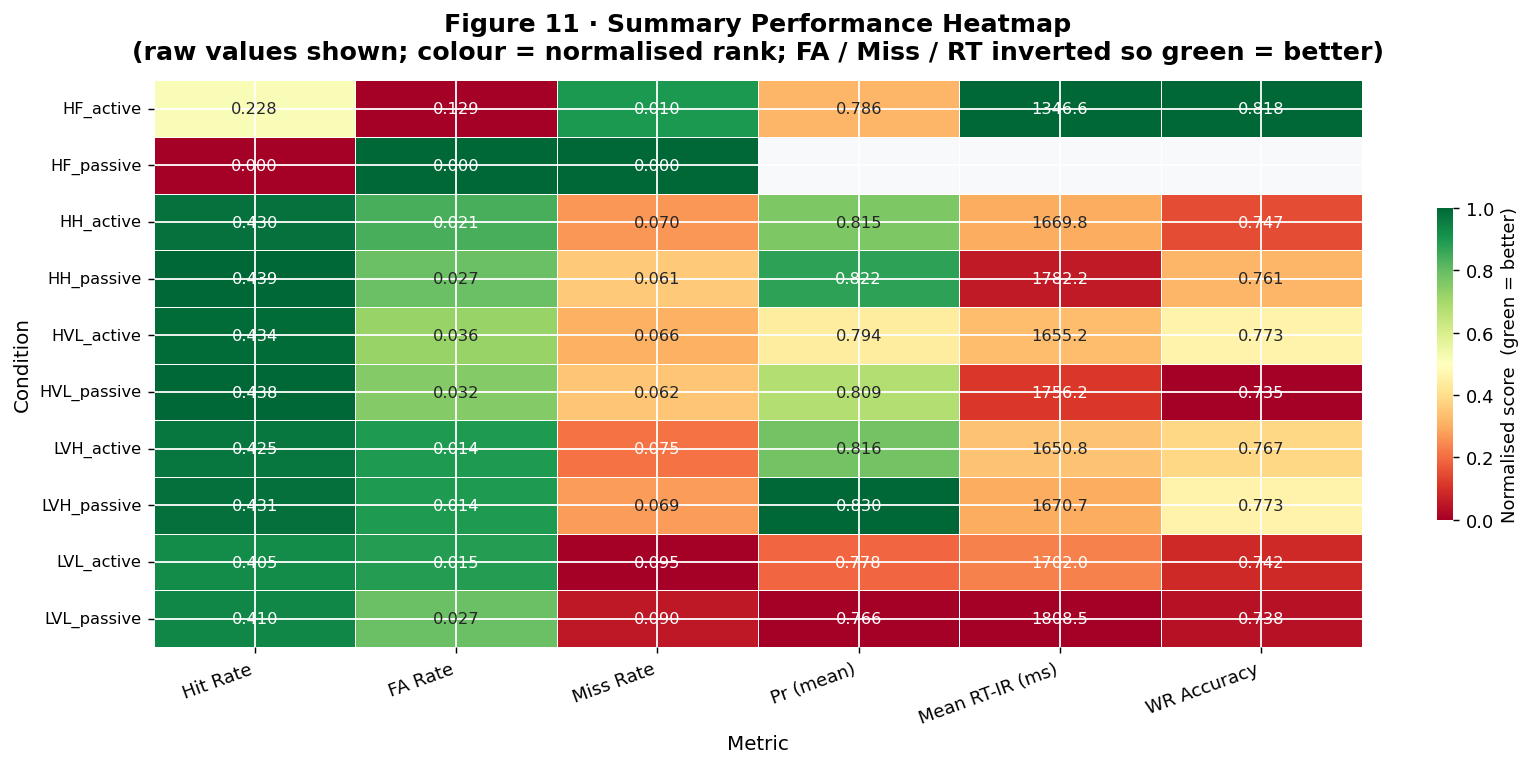

In [19]:
# ── Figure 11 · Summary Performance Heatmap ──────────────────────────────────
metrics = ["Hit Rate", "FA Rate", "Miss Rate", "Pr (mean)", "Mean RT-IR (ms)", "WR Accuracy"]
hm_raw  = summary_df[[c for c in metrics if c in summary_df.columns]].copy()

def norm01(s):
    vals = pd.to_numeric(s, errors="coerce")
    mn, mx = vals.min(), vals.max()
    return (vals - mn) / (mx - mn) if mx > mn else vals * 0 + 0.5

hm_norm = hm_raw.copy()
for col in hm_norm.columns:
    hm_norm[col] = norm01(hm_raw[col])

# Invert: lower FA / Miss / RT → better performance (green)
for col in ["FA Rate", "Miss Rate", "Mean RT-IR (ms)"]:
    if col in hm_norm.columns:
        hm_norm[col] = 1 - hm_norm[col]

# Build annotation from raw values (replace applymap with map on each column)
annot_df = hm_raw.copy().astype(object)
for col in annot_df.columns:
    if col == "Mean RT-IR (ms)":
        annot_df[col] = annot_df[col].map(lambda v: f"{v:.1f}" if pd.notna(v) else "—")
    else:
        annot_df[col] = annot_df[col].map(lambda v: f"{v:.3f}" if pd.notna(v) else "—")

fig, ax = plt.subplots(figsize=(13, max(6, len(FULL_CONDS) * 0.55)))
sns.heatmap(
    hm_norm.astype(float),
    annot=annot_df.values, fmt="",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"label": "Normalised score  (green = better)", "shrink": 0.55},
    annot_kws={"fontsize": 9}
)
ax.set_title(
    "Figure 11 · Summary Performance Heatmap\n"
    "(raw values shown; colour = normalised rank; FA / Miss / RT inverted so green = better)",
    **FONT_TITLE
)
ax.set_xlabel("Metric", **FONT_LABEL)
ax.set_ylabel("Condition", **FONT_LABEL)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=10)
ax.set_yticklabels(FULL_CONDS, rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("fig11_summary_heatmap.png", bbox_inches="tight")
plt.show()


---
## Summary of Analysis & Interpretation

### Analysis Overview

| Step | Procedure | Output |
|------|-----------|--------|
| Quality check | Block validation: Hits > FA/2 + Misses | % valid blocks / participants |
| Memorability | Pr = Hit Rate − FA Rate (per ppt × condition) | Bias-corrected recognition score |
| Omnibus test | Kruskal–Wallis H (α = .05) across 8 conditions | H, p, ε² |
| Word mem. test | Kruskal–Wallis across 4 conditions (HH/HL/LH/LL) | H, p, ε² + pairwise |
| Voice test | Wilcoxon signed-rank (paired; active vs. passive) | W, p |
| Post-hoc | Mann–Whitney U, Bonferroni-corrected | Pairwise p-values (Figure 7) |
| Convergent RT | Violin/box of IR RT by condition (Hits only) | Figure 8 |
| Verbatim memory | WR accuracy (exact vs. voice-transformed) | Figure 9 |
| Variability | Sentence-level Pr raindrop by condition + voice | Figure 10 |

### Interpreting Outcomes

**H1 (Word Memorability Effect):** An ordered pattern HH > {HL, LH} > LL in Pr, supported by
significant Kruskal–Wallis H with post-hoc contrasts isolating HH vs. LL, would confirm that
noun memorability propagates to whole-sentence recognition. Comparing HL vs. LH reveals whether
the **subject noun** (structurally prominent in active sentences) contributes more than the
**object noun**.

**H2 (Voice Effect):** Significantly higher Pr for active than passive sentences (Wilcoxon
signed-rank) would confirm that canonical sentence structure facilitates memory. A non-significant
result would suggest that voice transformation does not systematically impair gist recognition —
participants extract meaning regardless of voice.

**H3 (Interaction):** Non-parallel lines in Figure 6 (larger active–passive gap for HH/HL than
LL) would indicate that the voice effect is specifically amplified when the subject noun is
memorable — placing a highly memorable entity in the syntactically salient subject position
(active voice) provides an additive benefit beyond either manipulation alone.

---
*All analyses align with project specification. Kruskal–Wallis is the primary statistical test.
Corrected memorability (Pr) follows the recognition-memory norms tradition of the cited literature.*
